# Analise de Crimes Contra Vulneraveis no Brasil
## Analise Exploratoria Inicial (EDA)

**Equipe:** Sanderson Machado, Pedro Abreu, Arthur Cavalcante  
**Fonte:** SINESP — Sistema Nacional de Informacoes de Seguranca Publica  
**Periodo:** 2016-2025 | 2026 excluido (ano parcial: Jan-Mar apenas)  
**Granularidade:** Anual por Unidade Federativa (UF)

---

**Objetivo:** Explorar a distribuicao temporal e geografica dos crimes do SINESP,
identificar inconsistencias de subnotificacao, e preparar a base para correlacao com IBGE.

---
## 1. Importacoes e Configuracao

In [27]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR      = Path('../data/processed')
SINESP_FILE   = DATA_DIR / 'sinesp_crimes.csv'
ANO_INICIO    = 2018   # 2016-2017 excluidos: subnotificacao sistematica
ANO_FIM       = 2025   # 2026 excluido: ano parcial (Jan-Mar)
VAR_PRINCIPAL = 'estupro_vulneravel'

print(f'Janela de analise: {ANO_INICIO} a {ANO_FIM}')

Janela de analise: 2018 a 2025


---
## 2. Carregamento dos Dados

In [28]:
src_path = str((Path('..') / 'src').resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

if not SINESP_FILE.exists():
    print("sinesp_crimes.csv nao encontrado. Executando pipeline SINESP...")
    import load_and_standardize_sinesp
    load_and_standardize_sinesp.run()
else:
    print(f"sinesp_crimes.csv encontrado: {SINESP_FILE.resolve()}")

sinesp_crimes.csv encontrado: C:\Users\Usuário\Desktop\Dados_Crimes\data\processed\sinesp_crimes.csv


In [29]:
df_raw = pd.read_csv(SINESP_FILE)
df_raw['ano'] = df_raw['ano'].astype(int)
df_raw['uf']  = df_raw['uf'].astype(str)

print(f'Shape: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')
print(f'Colunas: {list(df_raw.columns)}')
print(f'Anos: {sorted(df_raw["ano"].unique())}')
print(f'UFs ({df_raw["uf"].nunique()}): {sorted(df_raw["uf"].unique())}')
df_raw.head(10)

Shape: 297 linhas x 10 colunas
Colunas: ['uf', 'ano', 'estupro', 'estupro_vulneravel', 'estupro_feminino', 'estupro_vulneravel_feminino', 'estupro_masculino', 'estupro_vulneravel_masculino', 'estupro_nao_informado', 'estupro_vulneravel_nao_informado']
Anos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
UFs (27): ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


,uf,ano,estupro,estupro_vulneravel,estupro_feminino,estupro_vulneravel_feminino,estupro_masculino,estupro_vulneravel_masculino,estupro_nao_informado,estupro_vulneravel_nao_informado
0,AC,2016,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,AC,2017,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,AC,2018,83,213,75.0,183.0,8.0,28.0,0.0,2.0
3,AC,2019,139,238,128.0,209.0,10.0,27.0,1.0,2.0
4,AC,2020,102,300,93.0,262.0,8.0,27.0,1.0,11.0
5,AC,2021,145,489,134.0,444.0,9.0,26.0,2.0,19.0
6,AC,2022,297,443,257.0,404.0,16.0,39.0,24.0,0.0
7,AC,2023,282,459,263.0,408.0,6.0,43.0,13.0,8.0
8,AC,2024,210,560,189.0,509.0,19.0,48.0,2.0,3.0
9,AC,2025,123,482,121.0,453.0,2.0,28.0,0.0,1.0


---
## 3. Inspecao Inicial

In [30]:
print('=== Tipos de dados ===')
print(df_raw.dtypes)
print()
df_raw.info()

=== Tipos de dados ===
uf                                      str
ano                                   int64
estupro                               int64
estupro_vulneravel                    int64
estupro_feminino                    float64
estupro_vulneravel_feminino         float64
estupro_masculino                   float64
estupro_vulneravel_masculino        float64
estupro_nao_informado               float64
estupro_vulneravel_nao_informado    float64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   uf                                297 non-null    str    
 1   ano                               297 non-null    int64  
 2   estupro                           297 non-null    int64  
 3   estupro_vulneravel                297 non-null    int64  
 4   estupro_feminino                  297 non-nul

In [31]:
dupl = df_raw.duplicated(subset=['uf', 'ano']).sum()
combos_reais     = len(df_raw)
combos_esperados = 27 * df_raw['ano'].nunique()
print(f'Duplicatas (uf+ano): {dupl}')
print(f'Combinacoes esperadas: {combos_esperados} | presentes: {combos_reais}')

Duplicatas (uf+ano): 0
Combinacoes esperadas: 297 | presentes: 297


---
## 4. Qualidade dos Dados

Tres dimensoes verificadas:
1. **Valores nulos** - ausencia de dados
2. **Cobertura temporal** - quais UFs reportaram em cada ano
3. **Zeros sistematicos** - UFs com zero (falha de notificacao vs ausencia real)

In [32]:
nulos = df_raw.isnull().sum()
print('Nulos por coluna:')
print(nulos)
print(f'\nTotal: {nulos.sum()} ({nulos.sum()/df_raw.size*100:.1f}% das celulas)')

Nulos por coluna:
uf                                  0
ano                                 0
estupro                             0
estupro_vulneravel                  0
estupro_feminino                    0
estupro_vulneravel_feminino         0
estupro_masculino                   0
estupro_vulneravel_masculino        0
estupro_nao_informado               0
estupro_vulneravel_nao_informado    0
dtype: int64

Total: 0 (0.0% das celulas)


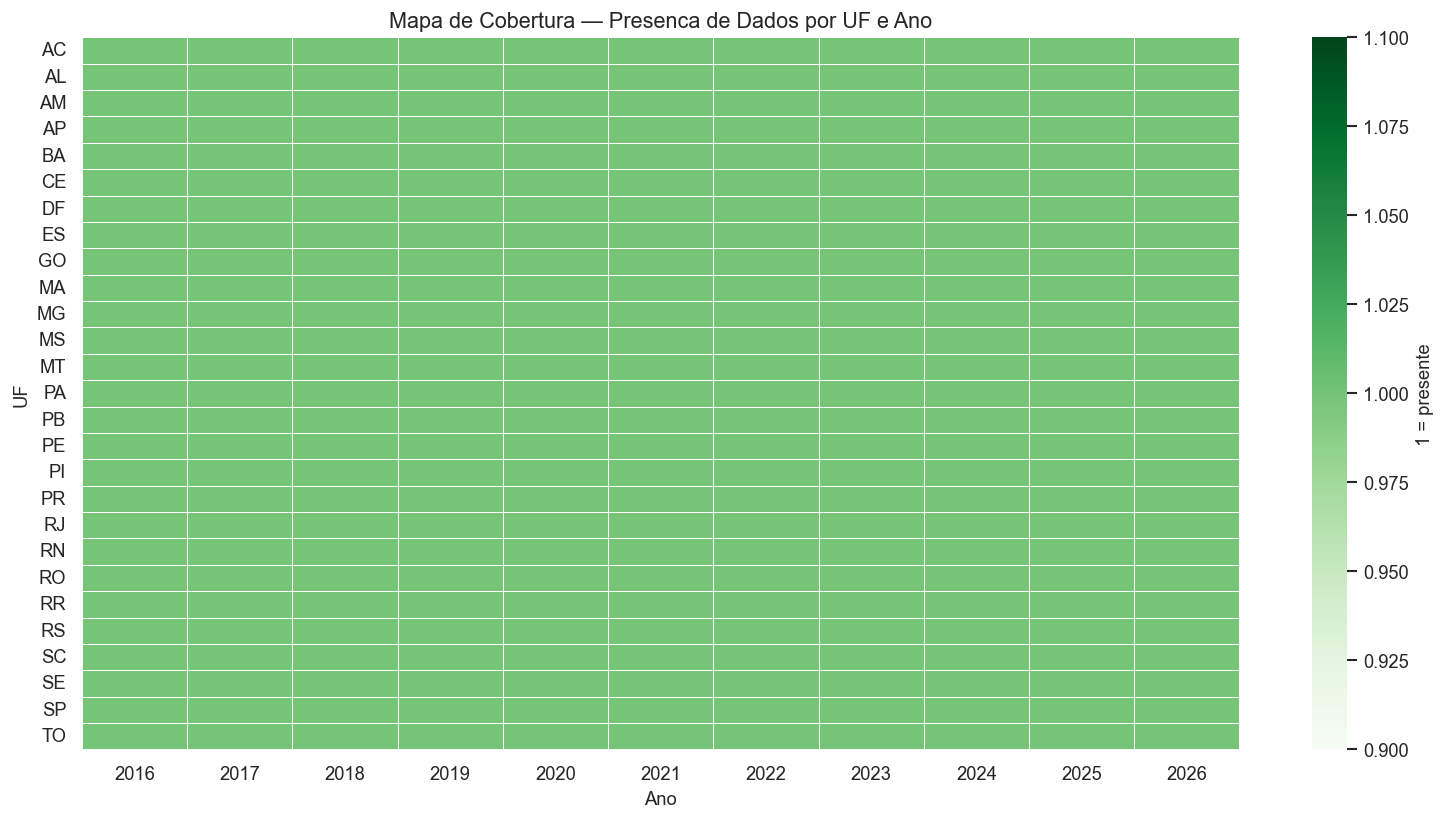

In [33]:
cobertura = df_raw.pivot_table(
    index='uf', columns='ano', values=VAR_PRINCIPAL, aggfunc='sum')
mascara = (~cobertura.isnull()).astype(int)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(mascara, annot=False, cmap='Greens', linewidths=0.4,
            cbar_kws={'label': '1 = presente'}, ax=ax)
ax.set_title('Mapa de Cobertura — Presenca de Dados por UF e Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('UF')
plt.tight_layout(); plt.show()

In [34]:
zeros = (
    df_raw[df_raw[VAR_PRINCIPAL] == 0]
    .groupby('ano')['uf']
    .apply(lambda x: sorted(x.tolist()))
)
print(f'UFs com {VAR_PRINCIPAL} = 0 por ano:')
for ano, ufs in zeros.items():
    print(f'  {ano}: {len(ufs)} UF(s) -> {ufs}')
print('\nNOTA: RJ = zero em todos os anos. Tratado como NaN (falha de notificacao).')

UFs com estupro_vulneravel = 0 por ano:
  2016: 10 UF(s) -> ['AC', 'AP', 'DF', 'ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2017: 10 UF(s) -> ['AC', 'AP', 'DF', 'ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2018: 8 UF(s) -> ['AP', 'ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2019: 7 UF(s) -> ['ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2020: 6 UF(s) -> ['ES', 'MA', 'MS', 'PB', 'RJ', 'RO']
  2021: 4 UF(s) -> ['ES', 'PB', 'RJ', 'RO']
  2022: 5 UF(s) -> ['ES', 'MS', 'PB', 'RJ', 'RO']
  2023: 4 UF(s) -> ['MS', 'PB', 'RJ', 'RO']
  2024: 4 UF(s) -> ['ES', 'MS', 'RJ', 'RO']
  2025: 1 UF(s) -> ['RJ']
  2026: 1 UF(s) -> ['RJ']

NOTA: RJ = zero em todos os anos. Tratado como NaN (falha de notificacao).


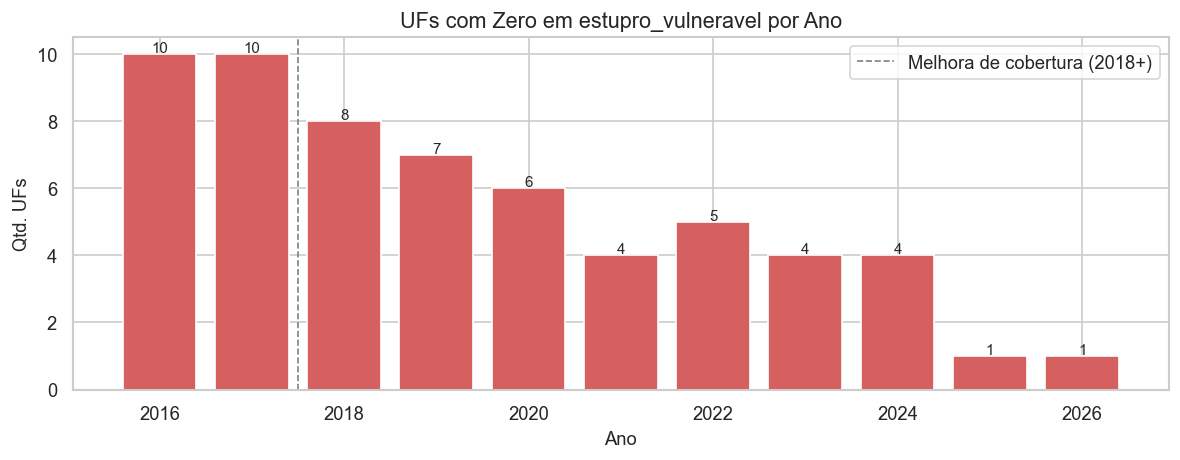

In [35]:
qtd_zeros = (
    df_raw[df_raw[VAR_PRINCIPAL] == 0]
    .groupby('ano')['uf'].count().reset_index(name='qtd')
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(qtd_zeros['ano'], qtd_zeros['qtd'],
       color=sns.color_palette('muted')[3], edgecolor='white')
ax.axvline(x=2017.5, color='gray', linestyle='--', linewidth=1,
           label='Melhora de cobertura (2018+)')
ax.set_title(f'UFs com Zero em {VAR_PRINCIPAL} por Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('Qtd. UFs')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
for b in ax.patches:
    if b.get_height() > 0:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                str(int(b.get_height())), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

### Decisao: Janela de Analise

| Periodo | Problema | Decisao |
|---|---|---|
| 2016-2017 | 10 UFs com zeros sistematicos | Excluidos das analises de tendencia |
| 2026 | Ano parcial (Jan-Mar) | Excluido de comparacoes anuais |
| RJ (todos os anos) | Zero em todos os anos | Marcado como NaN |

**Janela principal: 2018-2025** (8 anos, melhor cobertura)

In [36]:
df = df_raw[
    (df_raw['ano'] >= ANO_INICIO) & (df_raw['ano'] <= ANO_FIM)
].copy()
df.loc[df['uf'] == 'RJ', VAR_PRINCIPAL] = np.nan

print(f'df_raw       : {df_raw.shape}')
print(f'df (filtrado): {df.shape}')
print(f'Periodo      : {df["ano"].min()} a {df["ano"].max()}')

df_raw       : (297, 10)
df (filtrado): (216, 10)
Periodo      : 2018 a 2025


---
## 5. Estatisticas Descritivas

In [37]:
df[['estupro', 'estupro_vulneravel']].describe().round(1)

,estupro,estupro_vulneravel
count,216.0,208.0
mean,1051.9,1944.7
std,1191.6,2376.1
min,83.0,0.0
25%,261.8,492.0
50%,695.5,1063.0
75%,1345.8,2761.2
max,5867.0,12452.0


In [38]:
totais = df.groupby('ano')[['estupro','estupro_vulneravel']].sum()
totais['prop_vulneravel'] = (
    totais['estupro_vulneravel'] /
    (totais['estupro'] + totais['estupro_vulneravel'])
).round(3)
print('Totais nacionais por ano (2018-2025):')
print(totais.to_string())
print(f'\nMedia anual - estupro_vulneravel: {totais["estupro_vulneravel"].mean():,.0f}')
print(f'Proporcao media estupro_vuln    : {totais["prop_vulneravel"].mean():.1%}')

Totais nacionais por ano (2018-2025):
      estupro  estupro_vulneravel  prop_vulneravel
ano                                               
2018    31968             40848.0            0.561
2019    32848             44702.0            0.576
2020    25228             41900.0            0.624
2021    27511             45093.0            0.621
2022    27391             53146.0            0.660
2023    28690             59779.0            0.676
2024    29440             59666.0            0.670
2025    24126             59366.0            0.711

Media anual - estupro_vulneravel: 50,562
Proporcao media estupro_vuln    : 63.7%


In [39]:
media_uf = (
    df.groupby('uf')[['estupro','estupro_vulneravel']]
    .mean().round(0)
    .sort_values(VAR_PRINCIPAL, ascending=False)
)
print('Media anual por UF (2018-2025):')
media_uf

Media anual por UF (2018-2025):


,estupro,estupro_vulneravel
uf,,
SP,3289.0,11023.0
PR,1572.0,5572.0
RS,1318.0,4006.0
MG,1398.0,3970.0
PA,830.0,3556.0
GO,808.0,3074.0
BA,1339.0,3029.0
SC,2027.0,2909.0
PE,821.0,1987.0


---
## 6. Analise de Distribuicoes

Distribuicoes com assimetria > 1 podem exigir transformacao log antes do Pearson.

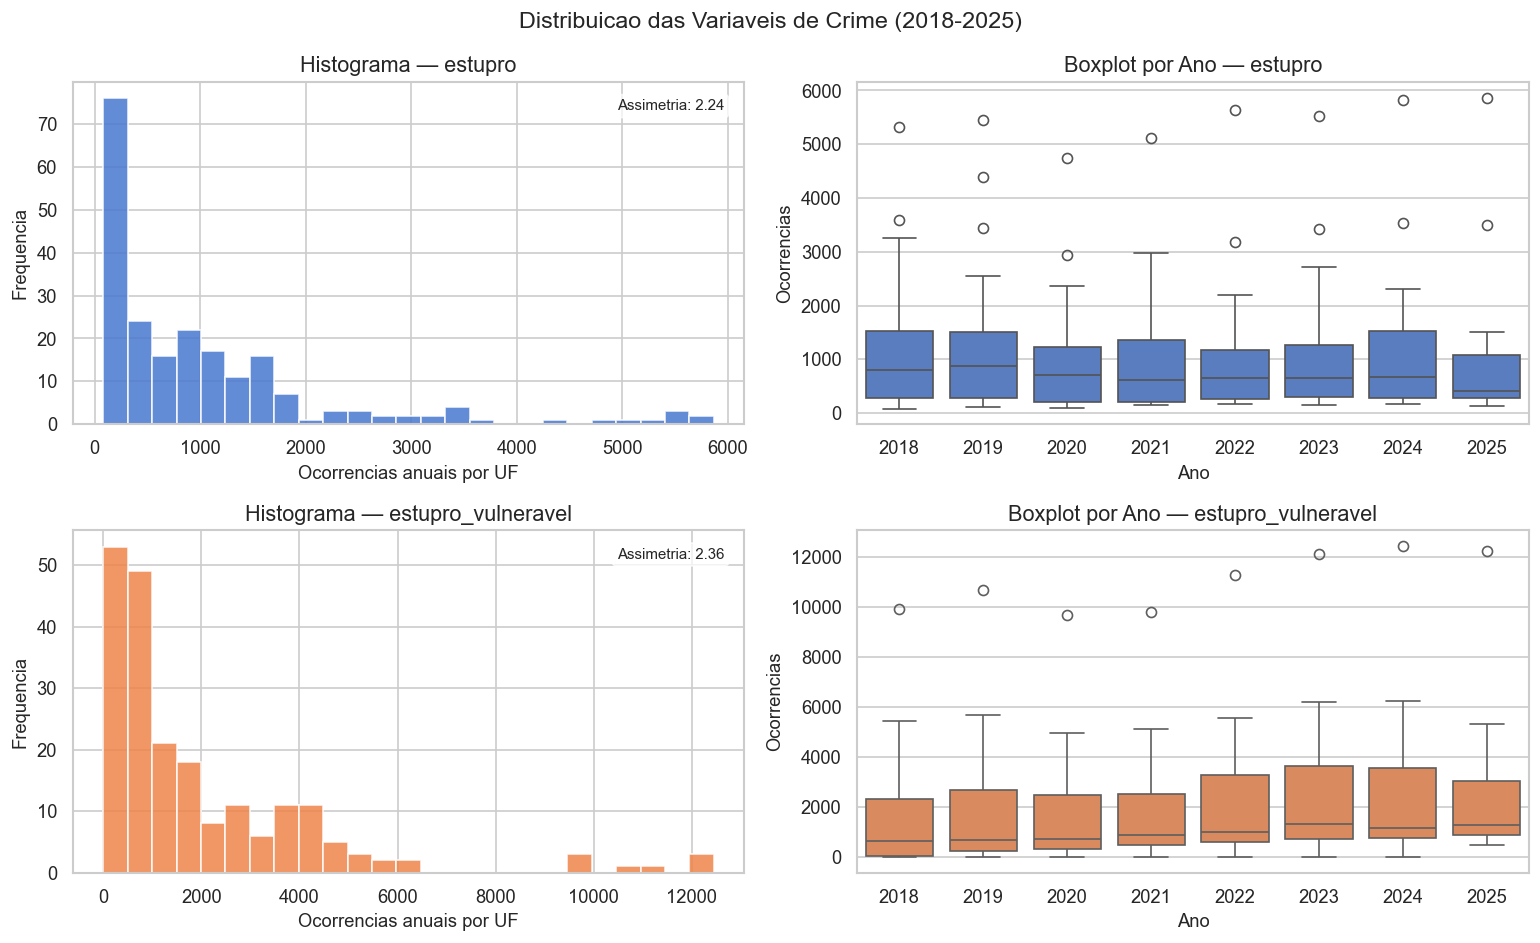


estupro: assimetria = 2.24  -> aplicar transformacao log
estupro_vulneravel: assimetria = 2.36  -> aplicar transformacao log


In [40]:
variaveis = ['estupro', 'estupro_vulneravel']
cores = sns.color_palette('muted', 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuicao das Variaveis de Crime (2018-2025)', fontsize=14)

for i, (var, cor) in enumerate(zip(variaveis, cores)):
    dados = df[var].dropna()
    sk    = dados.skew()

    axes[i,0].hist(dados, bins=25, color=cor, edgecolor='white', alpha=0.85)
    axes[i,0].set_title(f'Histograma — {var}')
    axes[i,0].set_xlabel('Ocorrencias anuais por UF')
    axes[i,0].set_ylabel('Frequencia')
    axes[i,0].text(0.97, 0.95, f'Assimetria: {sk:.2f}',
                   transform=axes[i,0].transAxes, ha='right', va='top',
                   fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    sns.boxplot(data=df[['ano',var]].dropna(), x='ano', y=var,
                color=cor, ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot por Ano — {var}')
    axes[i,1].set_xlabel('Ano'); axes[i,1].set_ylabel('Ocorrencias')

plt.tight_layout(); plt.show()
print()
for var in variaveis:
    sk = df[var].dropna().skew()
    rec = '-> aplicar transformacao log' if abs(sk) > 1 else '-> distribuicao aceitavel'
    print(f'{var}: assimetria = {sk:.2f}  {rec}')

---
## 7. Analise Temporal

Evolucao nacional e variacao YoY (ano a ano).

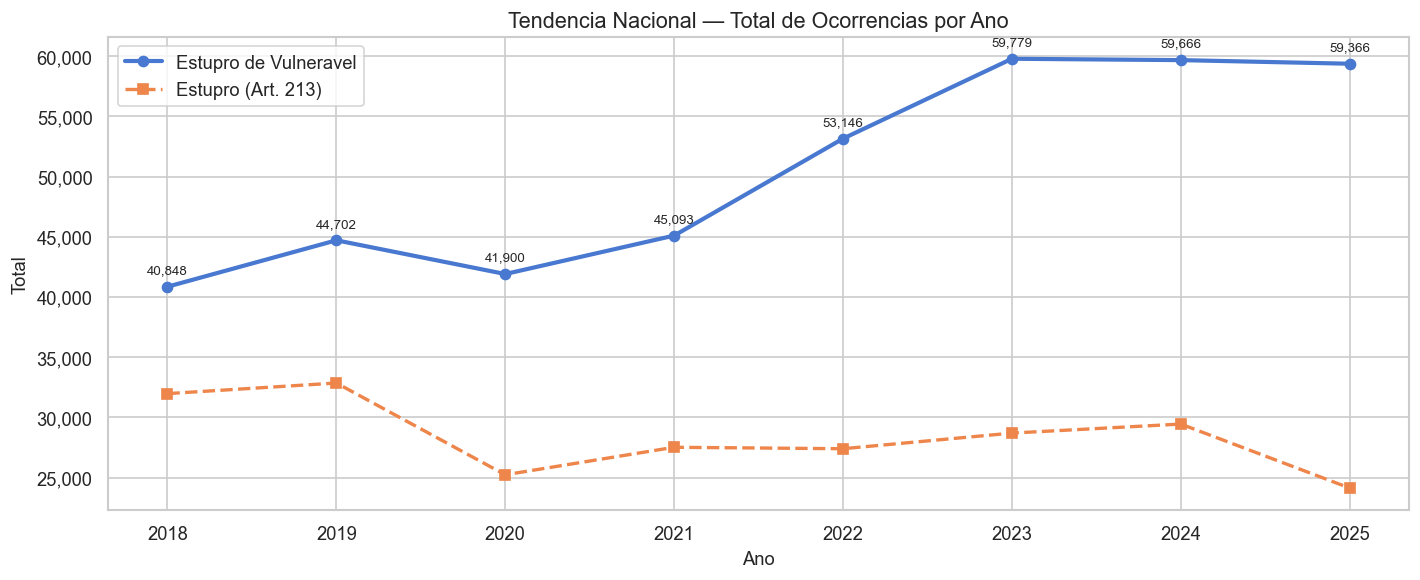

In [41]:
tendencia = df.groupby('ano')[['estupro','estupro_vulneravel']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tendencia['ano'], tendencia['estupro_vulneravel'],
        marker='o', linewidth=2.5, label='Estupro de Vulneravel',
        color=sns.color_palette('muted')[0])
ax.plot(tendencia['ano'], tendencia['estupro'],
        marker='s', linewidth=2, linestyle='--', label='Estupro (Art. 213)',
        color=sns.color_palette('muted')[1])
ax.set_title('Tendencia Nacional — Total de Ocorrencias por Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('Total')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_xticks(tendencia['ano']); ax.legend()
for _, row in tendencia.iterrows():
    ax.annotate(f"{row['estupro_vulneravel']:,.0f}",
                (row['ano'], row['estupro_vulneravel']),
                textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

In [42]:
tendencia['yoy_vuln']    = tendencia['estupro_vulneravel'].pct_change().mul(100).round(1)
tendencia['yoy_estupro'] = tendencia['estupro'].pct_change().mul(100).round(1)
print('Variacao percentual anual (YoY):')
print(tendencia[['ano','estupro_vulneravel','yoy_vuln','estupro','yoy_estupro']]
      .to_string(index=False))
cresc = (tendencia.iloc[-1]['estupro_vulneravel'] /
         tendencia.iloc[0]['estupro_vulneravel'] - 1) * 100
print(f'\nCrescimento total 2018->2025: {cresc:.1f}%')

Variacao percentual anual (YoY):
 ano  estupro_vulneravel  yoy_vuln  estupro  yoy_estupro
2018             40848.0       NaN    31968          NaN
2019             44702.0       9.4    32848          2.8
2020             41900.0      -6.3    25228        -23.2
2021             45093.0       7.6    27511          9.0
2022             53146.0      17.9    27391         -0.4
2023             59779.0      12.5    28690          4.7
2024             59666.0      -0.2    29440          2.6
2025             59366.0      -0.5    24126        -18.1

Crescimento total 2018->2025: 45.3%


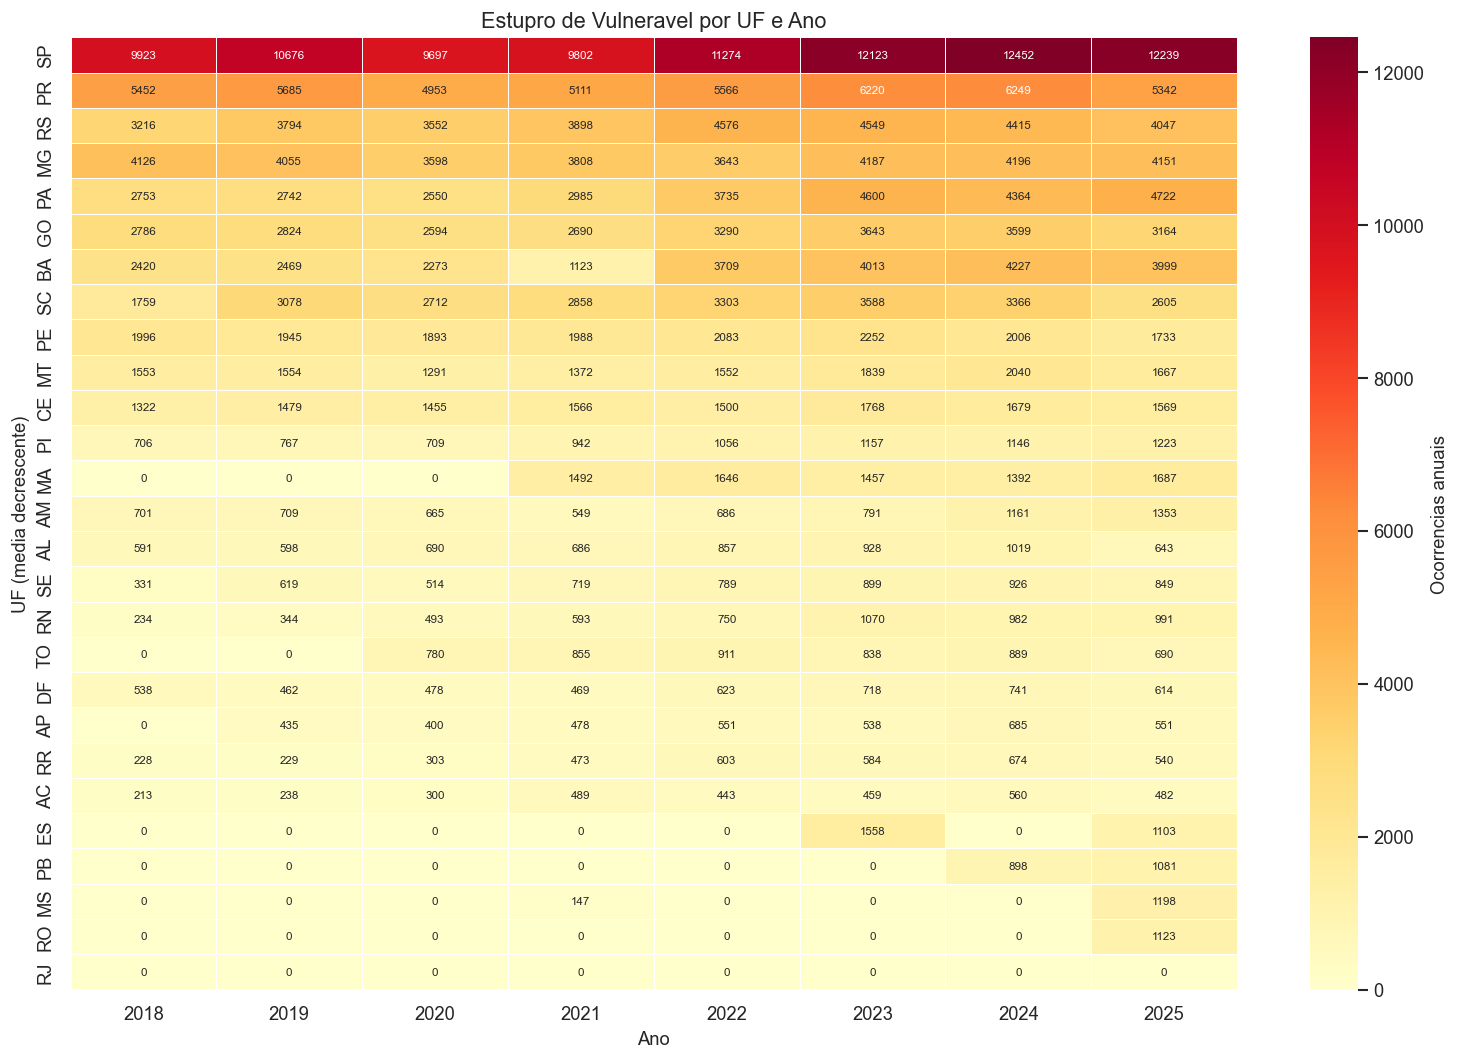

In [43]:
pivot = df.pivot_table(index='uf', columns='ano',
                       values=VAR_PRINCIPAL, aggfunc='sum')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            annot=True, fmt='.0f', annot_kws={'size': 7},
            cbar_kws={'label': 'Ocorrencias anuais'}, ax=ax)
ax.set_title('Estupro de Vulneravel por UF e Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('UF (media decrescente)')
plt.tight_layout(); plt.show()

---
## 8. Analise Geografica

Ranking dos estados por total acumulado no periodo 2018-2025.

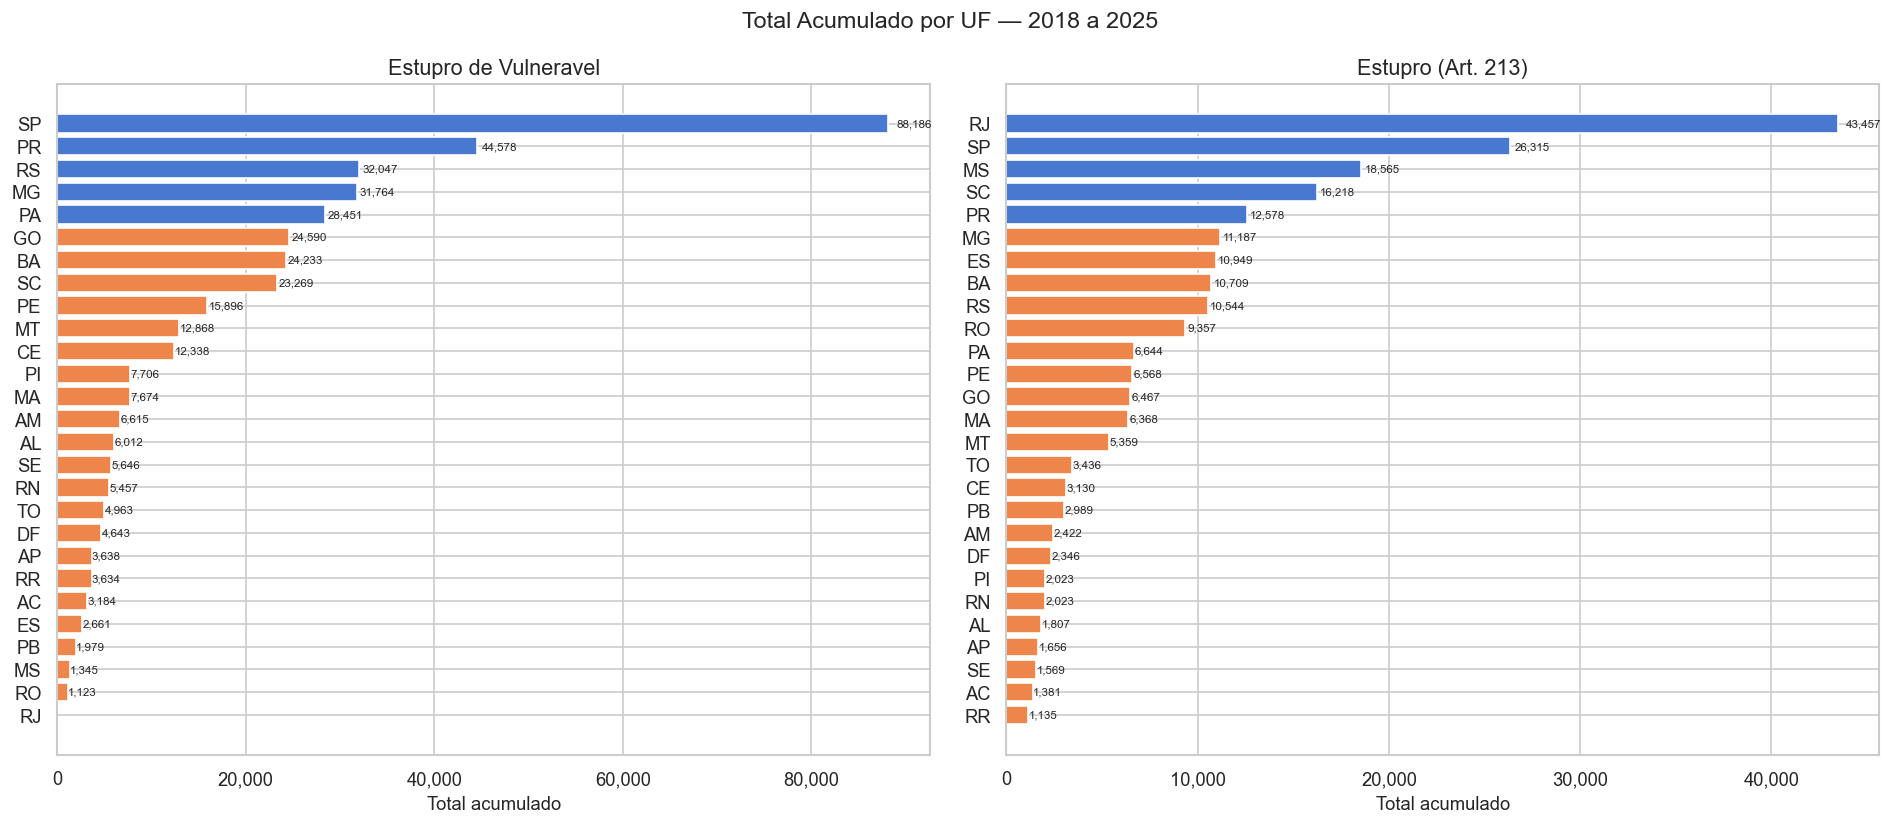

In [44]:
acum = (
    df.groupby('uf')[['estupro','estupro_vulneravel']]
    .sum().sort_values(VAR_PRINCIPAL, ascending=False).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Total Acumulado por UF — 2018 a 2025', fontsize=14)

for ax, var, titulo in zip(
    axes,
    ['estupro_vulneravel', 'estupro'],
    ['Estupro de Vulneravel', 'Estupro (Art. 213)']):

    dados = acum.sort_values(var, ascending=True)
    n     = len(dados)
    cores = [sns.color_palette('muted')[1]] * n
    for j in range(max(0, n-5), n): cores[j] = sns.color_palette('muted')[0]

    ax.barh(dados['uf'], dados[var], color=cores, edgecolor='white')
    ax.set_title(titulo); ax.set_xlabel('Total acumulado')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    for j, (_, row) in enumerate(dados.iterrows()):
        if row[var] > 0:
            ax.text(row[var]*1.01, j, f"{row[var]:,.0f}", va='center', fontsize=7)

plt.tight_layout(); plt.show()

In [45]:
sem_rj = acum[acum['uf'] != 'RJ']
print('=== TOP 5 — estupro_vulneravel (2018-2025) ===')
print(sem_rj.nlargest(5, VAR_PRINCIPAL)[['uf', VAR_PRINCIPAL]].to_string(index=False))
print('\n=== BOTTOM 5 ===')
print(sem_rj.nsmallest(5, VAR_PRINCIPAL)[['uf', VAR_PRINCIPAL]].to_string(index=False))
print('\nNOTA: volume absoluto e afetado por populacao.')
print('Taxa por 100k sera calculada apos incorporar dados do IBGE.')

=== TOP 5 — estupro_vulneravel (2018-2025) ===
uf  estupro_vulneravel
SP             88186.0
PR             44578.0
RS             32047.0
MG             31764.0
PA             28451.0

=== BOTTOM 5 ===
uf  estupro_vulneravel
RO              1123.0
MS              1345.0
PB              1979.0
ES              2661.0
AC              3184.0

NOTA: volume absoluto e afetado por populacao.
Taxa por 100k sera calculada apos incorporar dados do IBGE.


---
## 9. Analise de Correlacao

### 9a. Correlacao entre as variaveis de crime

Pearson e Spearman reportados — dados assimetricos requerem ambos.

In [46]:
dados_corr = df[['estupro', 'estupro_vulneravel']].dropna()
r_p, p_p = stats.pearsonr(dados_corr['estupro'], dados_corr['estupro_vulneravel'])
r_s, p_s = stats.spearmanr(dados_corr['estupro'], dados_corr['estupro_vulneravel'])

print('Correlacao: estupro vs estupro_vulneravel')
print(f'  Pearson  r = {r_p:.4f}  (p = {p_p:.4e})')
print(f'  Spearman r = {r_s:.4f}  (p = {p_s:.4e})')

#pearson comparação estrupro x estupro_vulneravel, para verificar se ambas crescem juntas (quanto mais crescer juntas, maior o r)
#spearman comparação estrupro x estupro_vulneravel, para verificar se ambas tem os rankings parecidos (ex: se uma UF tem mais estrupos, tem mais estupros de vulneravel?)
#quanto menor o p-value, menor a chance do resultado ter ocorrido por acaso

Correlacao: estupro vs estupro_vulneravel
  Pearson  r = 0.6247  (p = 6.5621e-24)
  Spearman r = 0.4261  (p = 1.3989e-10)


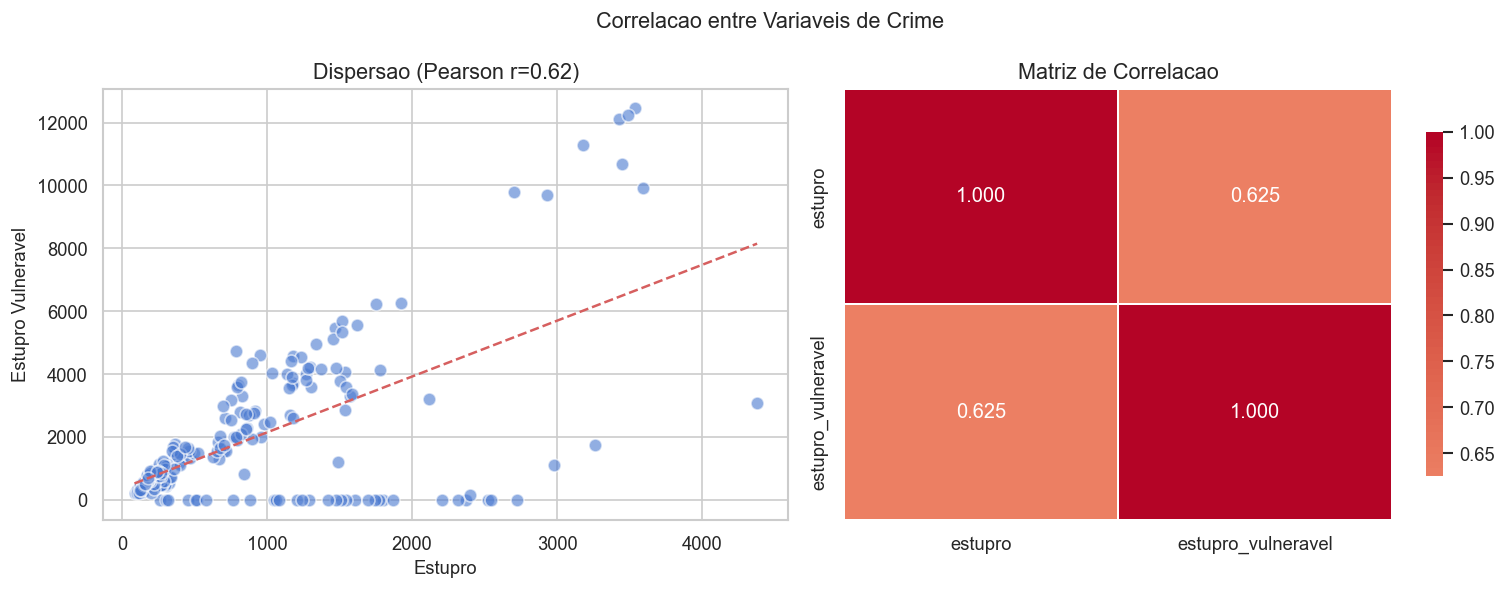

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Correlacao entre Variaveis de Crime', fontsize=13)

axes[0].scatter(dados_corr['estupro'], dados_corr['estupro_vulneravel'],
                alpha=0.6, color=sns.color_palette('muted')[0],
                edgecolors='white', s=60)
z  = np.polyfit(dados_corr['estupro'], dados_corr['estupro_vulneravel'], 1)
xl = np.linspace(dados_corr['estupro'].min(), dados_corr['estupro'].max(), 100)
axes[0].plot(xl, np.poly1d(z)(xl), 'r--', linewidth=1.5)
axes[0].set_title(f'Dispersao (Pearson r={r_p:.2f})')
axes[0].set_xlabel('Estupro'); axes[0].set_ylabel('Estupro Vulneravel')

sns.heatmap(dados_corr.corr(), annot=True, fmt='.3f',
            cmap='coolwarm', center=0, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title('Matriz de Correlacao')
plt.tight_layout(); plt.show()

#quanto mais proximo de 1 o 0.625 ou -1 for, mais um tende a aumentar junto ao outro.

---
## 9b. Correlacao com INSE (Indicador de Nivel Socioeconomico — INEP)

**Dataset:** `sinesp_inse_pop_inner_join.csv`  
**Granularidade:** 27 UFs x 2 anos (2019 e 2021) — 54 observacoes

> **Limitacao importante:** O INSE esta disponivel apenas para 2019 e 2021 (Censo Escolar INEP).  
> Os resultados devem ser interpretados com cautela: n reduzido (54), apenas 2 cortes temporais,  
> sem controle para fatores confundidores (populacao, infraestrutura policial, etc.).  
> **Correlacao nao implica causalidade.**

Variaveis dependentes: `taxa_estupro_por_100k` e `taxa_estupro_vulneravel_por_100k` (taxas por 100k hab.).  
Variaveis independentes: `inse` (score agregado estadual) e `percentual_nivel_1` a `percentual_nivel_8`.

In [71]:
INNER_POP_FILE = DATA_DIR / 'sinesp_inse_pop_inner_join.csv'

df_inse = pd.read_csv(INNER_POP_FILE)
df_inse['ano'] = df_inse['ano'].astype(int)
df_inse['uf'] = df_inse['uf'].astype(str)

TAXAS_COLS = [
    'taxa_estupro_por_100k',
    'taxa_estupro_vulneravel_por_100k',
]

INSE_VARS = ['inse'] + [f'percentual_nivel_{i}' for i in range(1, 9)]

print(
    f'Shape: {df_inse.shape}  |  '
    f'Anos: {sorted(df_inse["ano"].unique())}  |  '
    f'UFs: {df_inse["uf"].nunique()}'
)

print(f'Colunas: {list(df_inse.columns)}\n')

desc = df_inse[TAXAS_COLS + ['inse']].describe()

display(
    desc.style
        .format('{:.3f}')
        .format('{:.1f}', subset=pd.IndexSlice[['count','mean','std','min','25%','50%','75%','max'], :])
)

Shape: (54, 23)  |  Anos: [np.int64(2019), np.int64(2021)]  |  UFs: 27
Colunas: ['uf', 'ano', 'estupro', 'estupro_vulneravel', 'estupro_feminino', 'estupro_vulneravel_feminino', 'estupro_masculino', 'estupro_vulneravel_masculino', 'estupro_nao_informado', 'estupro_vulneravel_nao_informado', 'inse', 'quantidade_alunos_inse', 'percentual_nivel_1', 'percentual_nivel_2', 'percentual_nivel_3', 'percentual_nivel_4', 'percentual_nivel_5', 'percentual_nivel_6', 'percentual_nivel_7', 'percentual_nivel_8', 'populacao', 'taxa_estupro_por_100k', 'taxa_estupro_vulneravel_por_100k']



,taxa_estupro_por_100k,taxa_estupro_vulneravel_por_100k,inse
count,54.0,54.0,54.0
mean,19.6,23.3,4.9
std,20.4,17.9,0.4
min,3.9,0.0,4.2
25%,7.4,10.6,4.6
50%,11.9,20.5,4.8
75%,20.9,36.5,5.2
max,91.5,72.5,5.6


In [49]:
registros = []
for taxa in TAXAS_COLS:
    for var in INSE_VARS:
        d = df_inse[[taxa, var]].dropna()
        r, p_val = stats.pearsonr(d[taxa], d[var])
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
        registros.append({
            'taxa': taxa.replace('taxa_', '').replace('_por_100k', ''),
            'variavel_inse': var,
            'r': round(r, 3),
            'p': round(p_val, 4),
            'sig': sig,
        })

df_pearson = pd.DataFrame(registros)
print('Correlacoes de Pearson — Taxas por 100k vs Variaveis INSE')
print(f'n = 54  |  anos: 2019 e 2021\n')
print(df_pearson.to_string(index=False))
print('\nSig: *** p<0.001  ** p<0.01  * p<0.05  n.s. nao significativo')

Correlacoes de Pearson — Taxas por 100k vs Variaveis INSE
n = 54  |  anos: 2019 e 2021

              taxa      variavel_inse      r      p  sig
           estupro               inse  0.259 0.0590 n.s.
           estupro percentual_nivel_1 -0.391 0.0034   **
           estupro percentual_nivel_2 -0.308 0.0234    *
           estupro percentual_nivel_3 -0.171 0.2163 n.s.
           estupro percentual_nivel_4  0.210 0.1270 n.s.
           estupro percentual_nivel_5  0.342 0.0113    *
           estupro percentual_nivel_6  0.236 0.0855 n.s.
           estupro percentual_nivel_7  0.185 0.1805 n.s.
           estupro percentual_nivel_8  0.098 0.4811 n.s.
estupro_vulneravel               inse  0.116 0.4020 n.s.
estupro_vulneravel percentual_nivel_1 -0.057 0.6810 n.s.
estupro_vulneravel percentual_nivel_2 -0.085 0.5419 n.s.
estupro_vulneravel percentual_nivel_3 -0.141 0.3076 n.s.
estupro_vulneravel percentual_nivel_4 -0.194 0.1603 n.s.
estupro_vulneravel percentual_nivel_5  0.066 0.6368 n.s.


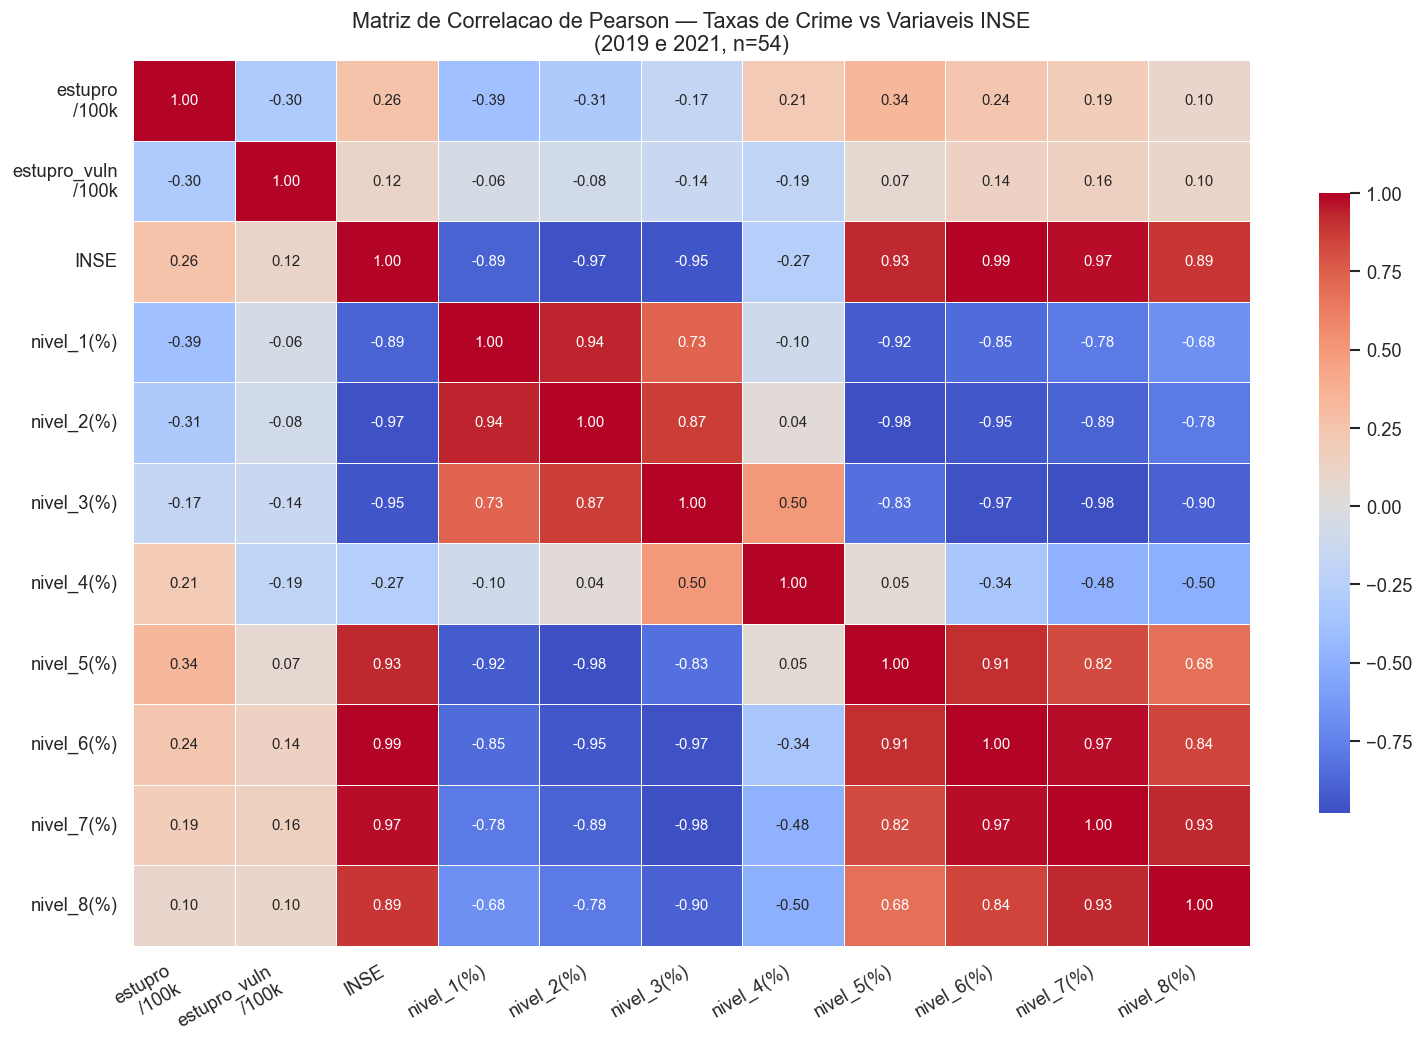

In [50]:
cols_matrix = TAXAS_COLS + INSE_VARS
corr_matrix = df_inse[cols_matrix].corr()

labels = {
    'taxa_estupro_por_100k': 'estupro\n/100k',
    'taxa_estupro_vulneravel_por_100k': 'estupro_vuln\n/100k',
    'inse': 'INSE',
}
labels.update({f'percentual_nivel_{i}': f'nivel_{i}(%)' for i in range(1, 9)})
corr_display = corr_matrix.rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(corr_display, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.7}, annot_kws={'size': 9}, ax=ax)
ax.set_title('Matriz de Correlacao de Pearson — Taxas de Crime vs Variaveis INSE\n'
             '(2019 e 2021, n=54)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

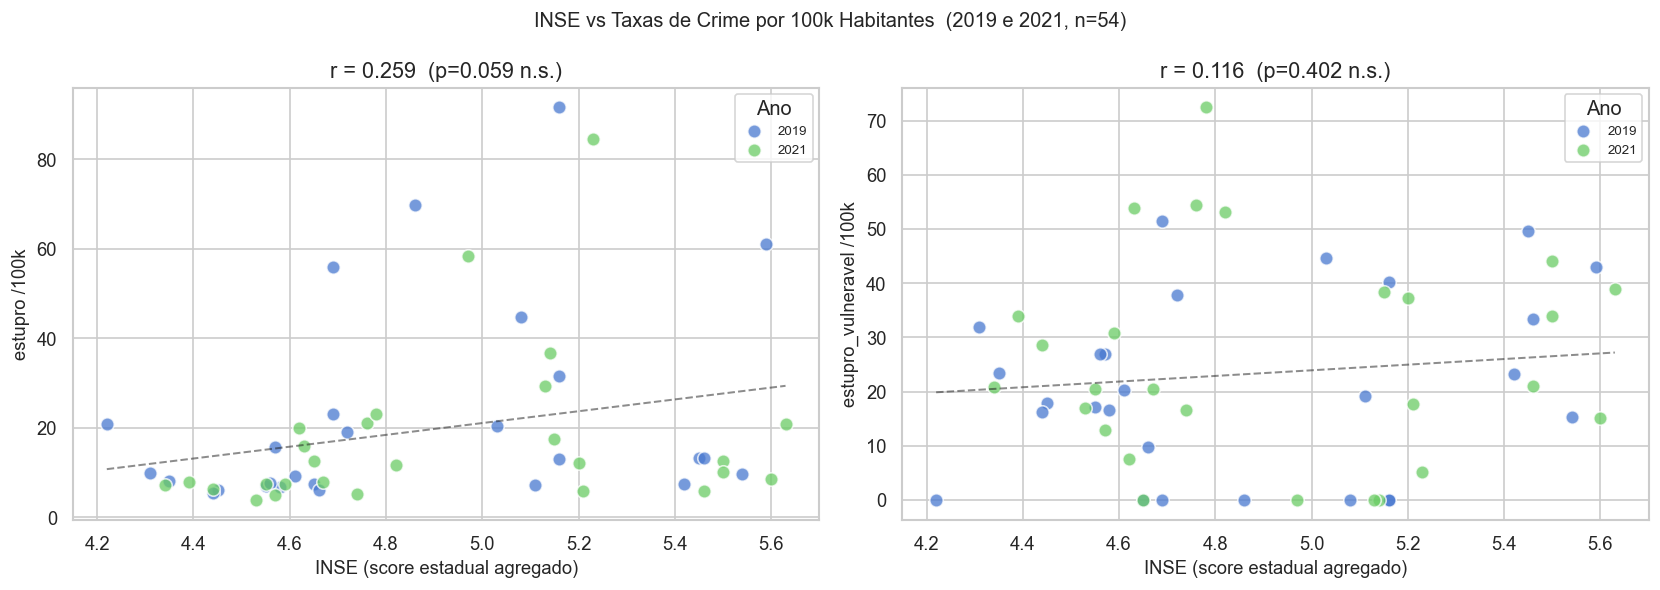

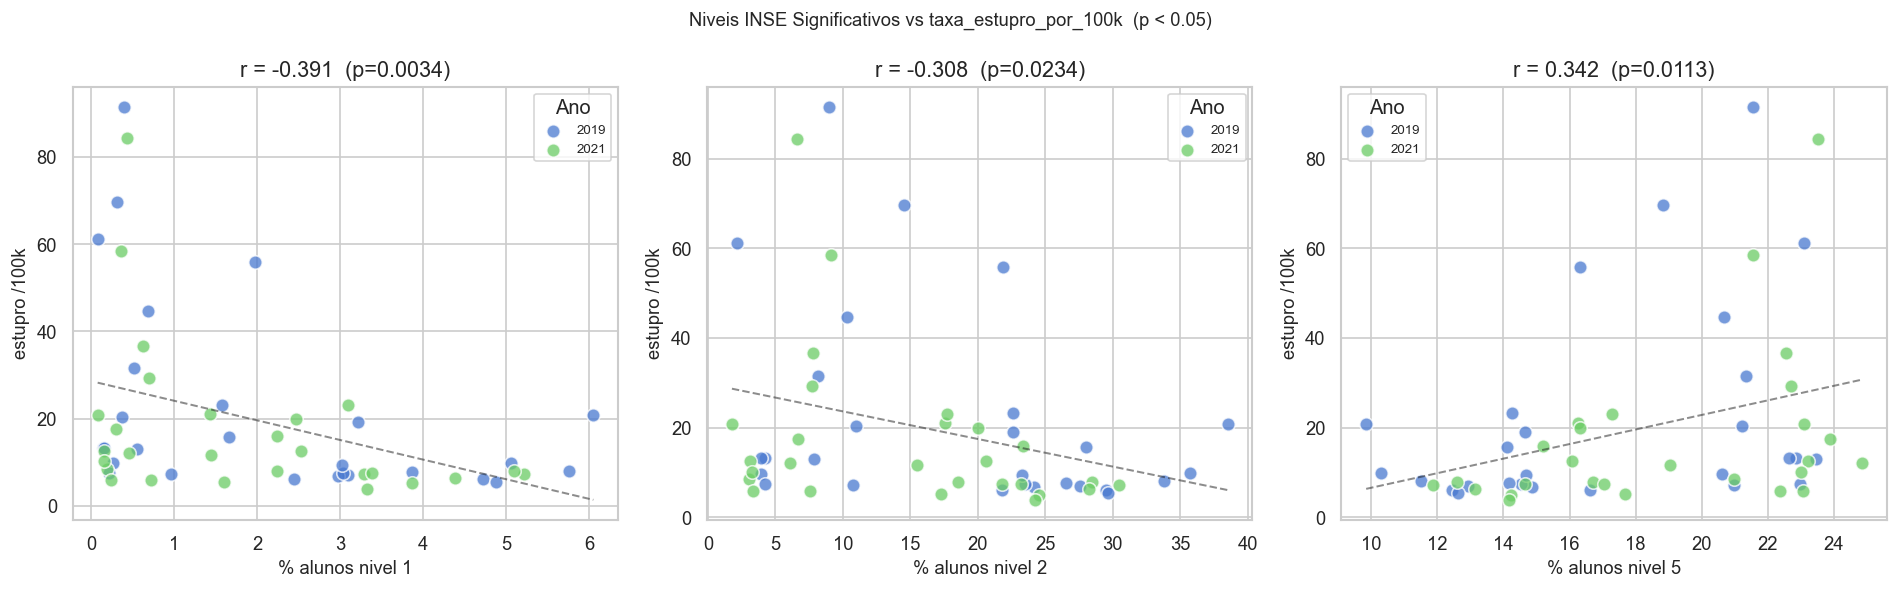

In [ ]:
_cores_ano = {2019: sns.color_palette('muted')[0], 2021: sns.color_palette('muted')[2]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('INSE vs Taxas de Crime por 100k Habitantes  (2019 e 2021, n=54)', fontsize=12)

for ax, taxa in zip(axes, TAXAS_COLS):
    for ano, cor in _cores_ano.items():
        sub = df_inse[df_inse['ano'] == ano]
        ax.scatter(sub['inse'], sub[taxa], color=cor, label=str(ano),
                   alpha=0.75, edgecolors='white', s=65)
    d = df_inse[['inse', taxa]].dropna()
    r, p_val = stats.pearsonr(d['inse'], d[taxa])
    z = np.polyfit(d['inse'], d[taxa], 1)
    xl = np.linspace(d['inse'].min(), d['inse'].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), 'k--', linewidth=1.2, alpha=0.5)
    sig = 'p<0.05' if p_val < 0.05 else f'p={p_val:.3f} n.s.'
    ax.set_xlabel('INSE (score estadual agregado)')
    ax.set_ylabel(taxa.replace('taxa_', '').replace('_por_100k', ' /100k'))
    ax.set_title(f'r = {r:.3f}  ({sig})')
    ax.legend(title='Ano', fontsize=8)

plt.tight_layout()
plt.show()

# Variaveis de nivel com p < 0.05 para taxa_estupro_por_100k
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Niveis INSE Significativos vs taxa_estupro_por_100k  (p < 0.05)', fontsize=11)

for ax, var_x in zip(axes2, ['percentual_nivel_1', 'percentual_nivel_2', 'percentual_nivel_5']):
    for ano, cor in _cores_ano.items():
        sub = df_inse[df_inse['ano'] == ano]
        ax.scatter(sub[var_x], sub['taxa_estupro_por_100k'], color=cor, label=str(ano),
                   alpha=0.75, edgecolors='white', s=65)
    d = df_inse[[var_x, 'taxa_estupro_por_100k']].dropna()
    r, p_val = stats.pearsonr(d[var_x], d['taxa_estupro_por_100k'])
    z = np.polyfit(d[var_x], d['taxa_estupro_por_100k'], 1)
    xl = np.linspace(d[var_x].min(), d[var_x].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), 'k--', linewidth=1.2, alpha=0.5)
    ax.set_xlabel(var_x.replace('percentual_nivel_', '% alunos nivel '))
    ax.set_ylabel('estupro /100k')
    ax.set_title(f'r = {r:.3f}  (p={p_val:.4f})')
    ax.legend(title='Ano', fontsize=8)

plt.tight_layout()
plt.show()

#### Resultados — Correlacao INSE x Taxas de Crime (2019 e 2021, n=54)

| Variavel INSE | r vs estupro/100k | Sig | r vs estupro_vuln/100k | Sig |
|---|---|---|---|---|
| inse (score agregado) | +0.259 | n.s. (p=0.059) | +0.116 | n.s. |
| percentual_nivel_1 | **-0.391** | ** (p=0.003) | -0.057 | n.s. |
| percentual_nivel_2 | **-0.308** | * (p=0.023) | -0.085 | n.s. |
| percentual_nivel_3 | -0.171 | n.s. | -0.141 | n.s. |
| percentual_nivel_4 | +0.210 | n.s. | -0.194 | n.s. |
| percentual_nivel_5 | **+0.342** | * (p=0.011) | +0.066 | n.s. |
| percentual_nivel_6 | +0.236 | n.s. | +0.140 | n.s. |
| percentual_nivel_7 | +0.185 | n.s. | +0.156 | n.s. |
| percentual_nivel_8 | +0.098 | n.s. | +0.103 | n.s. |

Sig: `**` p<0.01 · `*` p<0.05 · `n.s.` nao significativo

---

**Principais observacoes:**

1. **`taxa_estupro_vulneravel_por_100k` nao apresenta correlacao significativa com nenhuma variavel INSE.**
   Consistente com subnotificacao estrutural desse crime independente do nivel socioeconomico.

2. **`taxa_estupro_por_100k` apresenta correlacao negativa com `nivel_1` e `nivel_2` (niveis mais baixos do INSE)**
   e correlacao positiva com `nivel_5` (nivel intermediario-alto).
   Estados com maior proporcao de alunos nos niveis mais baixos registram *menos* esturos por 100k —
   sugestivo de **efeito de notificacao**: estados com maior infraestrutura institucional registram mais crimes,
   nao porque tenham mais crimes, mas porque tem maior capacidade de captacao e registro.

3. **O score INSE agregado esta proximo da significancia para `estupro` (p=0.059)**, com tendencia positiva —
   mesma direcao do efeito de notificacao.

**Interpretacao metodologica:**
O padrao observado e o inverso do esperado por uma hipotese simples "mais pobreza → mais crime registrado".
Isso e consistente com uma limitacao estrutural do SINESP: a subnotificacao e maior em regioes menos desenvolvidas.
Este resultado por si so nao permite afirmar que a pobreza reduz crimes.

> **n = 54 (27 UFs × 2 anos). Nao generalizar sem dados adicionais e sem controles socioeconomicos.**

---
## 10b. K-Means Definitivo — Perfis de Risco Observado

**Dataset:** `sinesp_inse_pop_inner_join.csv`  
**Observacoes:** 54 (27 UFs × 2 anos: 2019 e 2021)  
**Features:** taxas por 100k + indicadores INSE (nao contagens absolutas)  
**Metodo:** StandardScaler + K-Means (k avaliado: 2, 3, 4)

> **Limitacoes documentadas:**
> - INSE disponivel apenas para 2019 e 2021 (n=54 — amostra pequena).
> - Os clusters refletem **taxas de crimes registrados**, nao prevalencia real.
> - Capacidade de notificacao e infraestrutura policial afetam diretamente as taxas observadas.
> - Subnotificacao e um fator confundidor nao controlado nesta analise.
> - **Correlacao e clusterizacao nao implicam causalidade.**

In [52]:
CLUSTER_FILE = DATA_DIR / 'sinesp_inse_pop_inner_join.csv'

df_cl = pd.read_csv(CLUSTER_FILE)
df_cl['ano'] = df_cl['ano'].astype(int)
df_cl['uf']  = df_cl['uf'].astype(str)

FEAT_COLS = [
    'taxa_estupro_por_100k',
    'taxa_estupro_vulneravel_por_100k',
    'inse',
    'percentual_nivel_1',
    'percentual_nivel_2',
    'percentual_nivel_5',
]

X_raw_cl  = df_cl[FEAT_COLS].values
scaler_cl = StandardScaler()
X_scaled_cl = scaler_cl.fit_transform(X_raw_cl)

print(f'Observacoes: {len(df_cl)}  |  UFs: {df_cl["uf"].nunique()}  |  Anos: {sorted(df_cl["ano"].unique())}')
print(f'Nulos nas features: {np.isnan(X_scaled_cl).sum()}')
print(f'\nFeatures ({len(FEAT_COLS)}):')
for col in FEAT_COLS:
    print(f'  {col:<44}  mean={df_cl[col].mean():.3f}  std={df_cl[col].std():.3f}')

Observacoes: 54  |  UFs: 27  |  Anos: [np.int64(2019), np.int64(2021)]
Nulos nas features: 0

Features (6):
  taxa_estupro_por_100k                         mean=19.581  std=20.402
  taxa_estupro_vulneravel_por_100k              mean=23.336  std=17.892
  inse                                          mean=4.886  std=0.400
  percentual_nivel_1                            mean=2.001  std=1.773
  percentual_nivel_2                            mean=16.604  std=10.220
  percentual_nivel_5                            mean=17.983  std=4.300


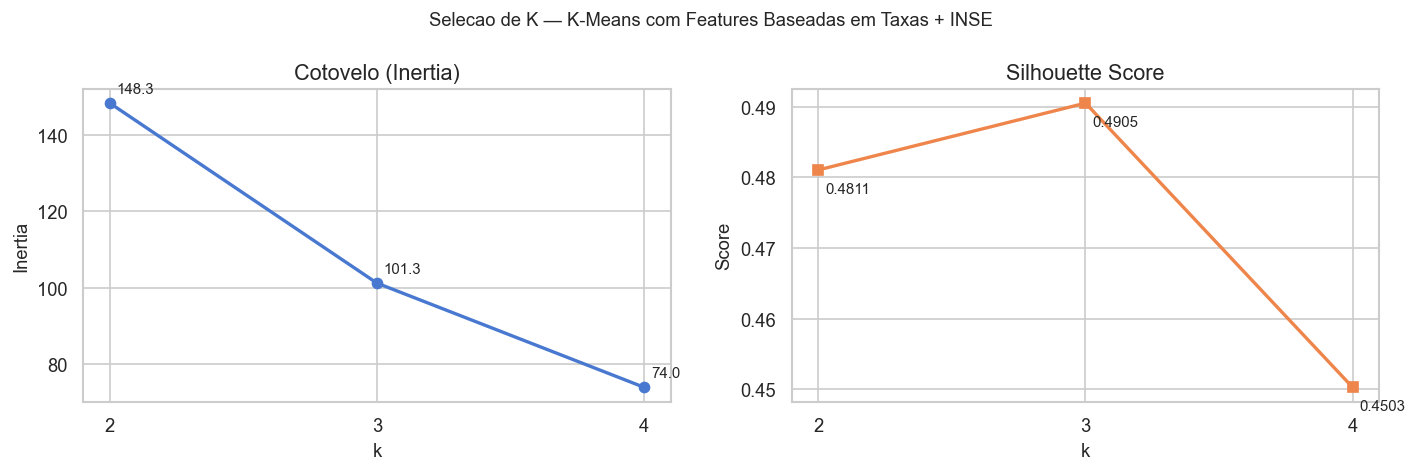

k  | inertia | silhouette
2  |  148.34 | 0.4811
3  |  101.26 | 0.4905 <- selecionado
4  |   74.02 | 0.4503


In [53]:
_k_range     = [2, 3, 4]
_inertias    = []
_silhouettes = []

for k in _k_range:
    _km = KMeans(n_clusters=k, random_state=42, n_init=20)
    _lbs = _km.fit_predict(X_scaled_cl)
    _inertias.append(_km.inertia_)
    _silhouettes.append(silhouette_score(X_scaled_cl, _lbs))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Selecao de K — K-Means com Features Baseadas em Taxas + INSE', fontsize=11)

axes[0].plot(_k_range, _inertias, marker='o', color=sns.color_palette('muted')[0], linewidth=2)
axes[0].set_title('Cotovelo (Inertia)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_xticks(_k_range)
for k, v in zip(_k_range, _inertias):
    axes[0].annotate(f'{v:.1f}', (k, v), textcoords='offset points', xytext=(4, 6), fontsize=9)

axes[1].plot(_k_range, _silhouettes, marker='s', color=sns.color_palette('muted')[1], linewidth=2)
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
axes[1].set_xticks(_k_range)
for k, v in zip(_k_range, _silhouettes):
    axes[1].annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(4, -14), fontsize=9)

plt.tight_layout(); plt.show()

print('k  | inertia | silhouette')
for k, ine, sil in zip(_k_range, _inertias, _silhouettes):
    flag = ' <- selecionado' if sil == max(_silhouettes) else ''
    print(f'{k}  | {ine:7.2f} | {sil:.4f}{flag}')

In [54]:
K_FINAL = 3
_km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_cl['cluster_id'] = _km_final.fit_predict(X_scaled_cl)

_vuln_means = df_cl.groupby('cluster_id')['taxa_estupro_vulneravel_por_100k'].mean().sort_values()
_LABEL_MAP = {
    int(_vuln_means.index[0]): 'Padrao atipico (inconsistencia de notificacao)',
    int(_vuln_means.index[1]): 'Risco observado mais baixo',
    int(_vuln_means.index[2]): 'Risco observado mais alto',
}
df_cl['perfil'] = df_cl['cluster_id'].map(_LABEL_MAP)

print(f'K={K_FINAL} | silhouette = {max(_silhouettes):.4f}')
print(f'\nMapa de rotulos:')
for cid, label in _LABEL_MAP.items():
    m = _vuln_means[cid]
    print(f'  cluster_id={cid}  taxa_estupro_vuln_media={m:.2f}  -> {label}')
print(f'\nDistribuicao:')
print(df_cl.groupby(['cluster_id','perfil']).agg(n_obs=('uf','count'), n_ufs=('uf','nunique')).to_string())

K=3 | silhouette = 0.4905

Mapa de rotulos:
  cluster_id=2  taxa_estupro_vuln_media=0.58  -> Padrao atipico (inconsistencia de notificacao)
  cluster_id=1  taxa_estupro_vuln_media=24.52  -> Risco observado mais baixo
  cluster_id=0  taxa_estupro_vuln_media=33.44  -> Risco observado mais alto

Distribuicao:
                                                           n_obs  n_ufs
cluster_id perfil                                                      
0          Risco observado mais alto                          17      9
1          Risco observado mais baixo                         28     14
2          Padrao atipico (inconsistencia de notificacao)      9      5


In [55]:
profile_cols = FEAT_COLS + ['estupro', 'estupro_vulneravel', 'populacao']

perfil_summary = df_cl.groupby('perfil')[profile_cols].mean().round(3).T
perfil_summary.index.name = 'feature'

print('Media das features por perfil de cluster:')
display(
    perfil_summary.style.format(
        lambda x: f'{x:,.3f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    )
)

Media das features por perfil de cluster:


perfil,Padrao atipico (inconsistencia de notificacao),Risco observado mais alto,Risco observado mais baixo
feature,,,
taxa_estupro_por_100k,"55,817","14,745","10,871"
taxa_estupro_vulneravel_por_100k,"0,575","33,443","24,515"
inse,"5,047","5,343","4,558"
percentual_nivel_1,"0,668","0,384","3,412"
percentual_nivel_2,"10,554","5,794","25,111"
percentual_nivel_5,"21,004","22,428","14,312"
estupro,"2.443,111","1.433,882","499,821"
estupro_vulneravel,"16,333","3.705,353","952,036"
populacao,"5.959.888,111","13.207.121,471","5.189.453,786"


In [56]:
tabela_cl = (
    df_cl[['uf', 'ano', 'perfil', 'cluster_id',
           'taxa_estupro_por_100k', 'taxa_estupro_vulneravel_por_100k', 'inse']]
    .copy()
)
tabela_cl['taxa_estupro_por_100k']            = tabela_cl['taxa_estupro_por_100k'].round(2)
tabela_cl['taxa_estupro_vulneravel_por_100k'] = tabela_cl['taxa_estupro_vulneravel_por_100k'].round(2)
tabela_cl['inse']                             = tabela_cl['inse'].round(3)
tabela_cl = tabela_cl.sort_values(['perfil', 'uf', 'ano']).reset_index(drop=True)

print('UFs por perfil de cluster:')
for perfil, grupo in tabela_cl.groupby('perfil'):
    ufs = sorted(grupo['uf'].unique().tolist())
    print(f'\n  {perfil}:')
    print(f'    UFs ({len(ufs)}): {ufs}')

print()
tabela_cl

UFs por perfil de cluster:

  Padrao atipico (inconsistencia de notificacao):
    UFs (5): ['ES', 'MS', 'RJ', 'RO', 'TO']

  Risco observado mais alto:
    UFs (9): ['DF', 'GO', 'MG', 'MT', 'PR', 'RS', 'SC', 'SP', 'TO']

  Risco observado mais baixo:
    UFs (14): ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'MA', 'PA', 'PB', 'PE', 'PI', 'RN', 'RR', 'SE']



,uf,ano,perfil,cluster_id,taxa_estupro_por_100k,taxa_estupro_vulneravel_por_100k,inse
0,ES,2019,Padrao atipico (inconsistencia de notificacao),2,44.72,0.00,5.08
1,ES,2021,Padrao atipico (inconsistencia de notificacao),2,36.75,0.00,5.14
2,MS,2019,Padrao atipico (inconsistencia de notificacao),2,91.54,0.00,5.16
3,MS,2021,Padrao atipico (inconsistencia de notificacao),2,84.46,5.18,5.23
4,RJ,2019,Padrao atipico (inconsistencia de notificacao),2,31.57,0.00,5.16
5,RJ,2021,Padrao atipico (inconsistencia de notificacao),2,29.26,0.00,5.13
6,RO,2019,Padrao atipico (inconsistencia de notificacao),2,69.72,0.00,4.86
7,RO,2021,Padrao atipico (inconsistencia de notificacao),2,58.45,0.00,4.97
8,TO,2019,Padrao atipico (inconsistencia de notificacao),2,55.89,0.00,4.69
9,DF,2019,Risco observado mais alto,0,9.72,15.32,5.54


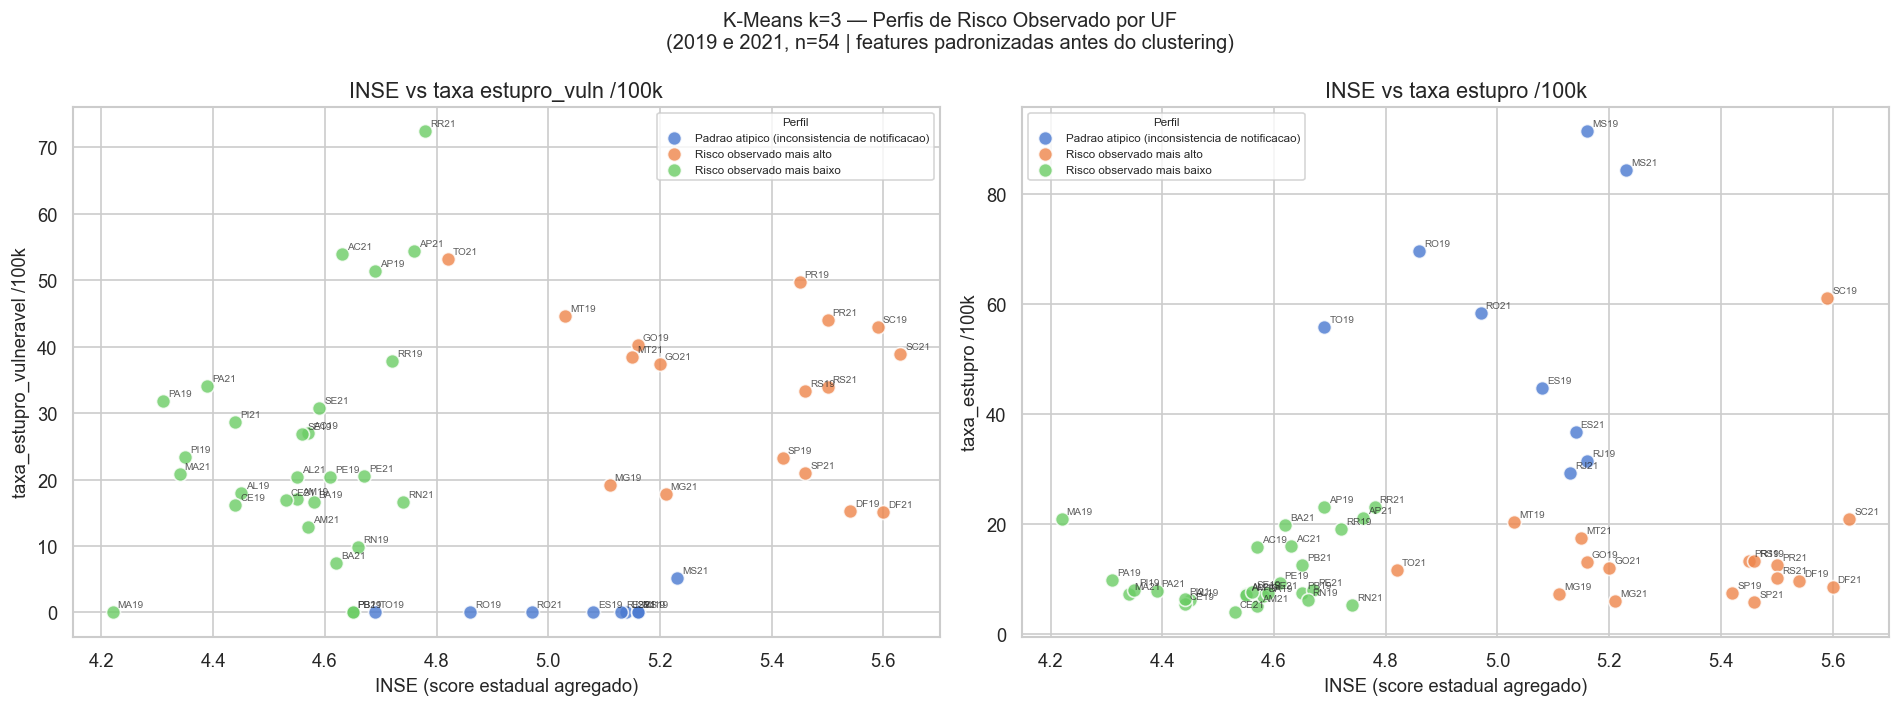

In [57]:
_paleta_perfil = dict(zip(
    sorted(df_cl['perfil'].unique()),
    sns.color_palette('muted', 3)
))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means k=3 — Perfis de Risco Observado por UF\n'
             '(2019 e 2021, n=54 | features padronizadas antes do clustering)', fontsize=12)

for ax, (var_x, var_y, titulo) in zip(axes, [
    ('inse', 'taxa_estupro_vulneravel_por_100k', 'INSE vs taxa estupro_vuln /100k'),
    ('inse', 'taxa_estupro_por_100k',            'INSE vs taxa estupro /100k'),
]):
    for perfil, cor in _paleta_perfil.items():
        sub = df_cl[df_cl['perfil'] == perfil]
        ax.scatter(sub[var_x], sub[var_y], color=cor, label=perfil,
                   alpha=0.8, edgecolors='white', s=70, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(
                f"{row['uf']}{str(row['ano'])[2:]}",
                (row[var_x], row[var_y]),
                fontsize=6, alpha=0.75,
                textcoords='offset points', xytext=(3, 3)
            )
    ax.set_xlabel('INSE (score estadual agregado)')
    ax.set_ylabel(var_y.replace('_por_100k', ' /100k'))
    ax.set_title(titulo)
    ax.legend(fontsize=7, title='Perfil', title_fontsize=7)

plt.tight_layout()
plt.show()

In [58]:
OUTPUT_CLUSTERS = DATA_DIR / 'sinesp_inse_pop_clusters.csv'
df_cl.to_csv(OUTPUT_CLUSTERS, index=False, encoding='utf-8')

print(f'Salvo -> {OUTPUT_CLUSTERS.resolve()}')
print(f'Shape: {df_cl.shape}')
print(f'Colunas: {list(df_cl.columns)}')
print(f'\nDistribuicao final dos perfis:')
print(df_cl['perfil'].value_counts().to_string())

Salvo -> C:\Users\Usuário\Desktop\Dados_Crimes\data\processed\sinesp_inse_pop_clusters.csv
Shape: (54, 25)
Colunas: ['uf', 'ano', 'estupro', 'estupro_vulneravel', 'estupro_feminino', 'estupro_vulneravel_feminino', 'estupro_masculino', 'estupro_vulneravel_masculino', 'estupro_nao_informado', 'estupro_vulneravel_nao_informado', 'inse', 'quantidade_alunos_inse', 'percentual_nivel_1', 'percentual_nivel_2', 'percentual_nivel_3', 'percentual_nivel_4', 'percentual_nivel_5', 'percentual_nivel_6', 'percentual_nivel_7', 'percentual_nivel_8', 'populacao', 'taxa_estupro_por_100k', 'taxa_estupro_vulneravel_por_100k', 'cluster_id', 'perfil']

Distribuicao final dos perfis:
perfil
Risco observado mais baixo                        28
Risco observado mais alto                         17
Padrao atipico (inconsistencia de notificacao)     9


#### Resultados do Clustering K-Means (k=3, silhouette=0.4905)

| Perfil | n obs | UFs | taxa_estupro_vuln/100k (media) | INSE (media) |
|---|---|---|---|---|
| Risco observado mais alto | 17 | DF, GO, MG, MT, PR, RS, SC, SP, TO* | 33.44 | 5.34 |
| Risco observado mais baixo | 28 | AC, AL, AM, AP, BA, CE, MA, PA, PB, PE, PI, RN, RR, SE | 24.52 | 4.56 |
| Padrao atipico | 9 | ES, MS, RJ, RO, TO* | ~0.58 | 5.05 |

*TO aparece em perfis diferentes entre 2019 e 2021 — indicativo de instabilidade nas bordas do cluster.

**Interpretacao:**

- **Risco observado mais alto:** Predominantemente Sul, Sudeste e Centro-Oeste, com maior INSE
  e maiores taxas registradas de estupro_vulneravel por 100k.
  A taxa elevada provavelmente reflete melhor infraestrutura de notificacao, nao necessariamente maior incidencia real.

- **Risco observado mais baixo:** Norte e Nordeste, menor INSE e menores taxas registradas.
  Pode refletir subnotificacao estrutural, nao ausencia de crimes.

- **Padrao atipico:** ES, MS, RJ, RO apresentam alta taxa de estupro por 100k mas taxa de
  estupro_vulneravel proxima de zero — sinal de falha grave de notificacao desta categoria especifica.
  RJ tem zero registros de estupro_vulneravel em todos os anos do SINESP.

> **Nota:** Os clusters nao devem ser interpretados como grupos de risco real sem controlar por
> capacidade de notificacao, infraestrutura policial e fatores socioeconomicos nao observados.
> **Correlacao e clusterizacao nao implicam causalidade.**

---
## 10. Preparacao para Clusterizacao (K-Means)

Matriz de features preliminar baseada apenas em crimes.
Sera expandida com variaveis do IBGE antes da clusterizacao definitiva.

In [59]:
feat = (
    df[df['uf'] != 'RJ']
    .groupby('uf')[['estupro', 'estupro_vulneravel']]
    .mean().dropna()
)
scaler     = StandardScaler()
feat_scaled = pd.DataFrame(
    scaler.fit_transform(feat),
    index=feat.index, columns=feat.columns
)
print(f'Estados na matriz: {len(feat)}')
feat_scaled.head()

Estados na matriz: 26


,estupro,estupro_vulneravel
uf,,
AC,-0.926927,-0.665924
AL,-0.857483,-0.513728
AM,-0.757228,-0.481276
AP,-0.882098,-0.641491
BA,0.593685,0.466885


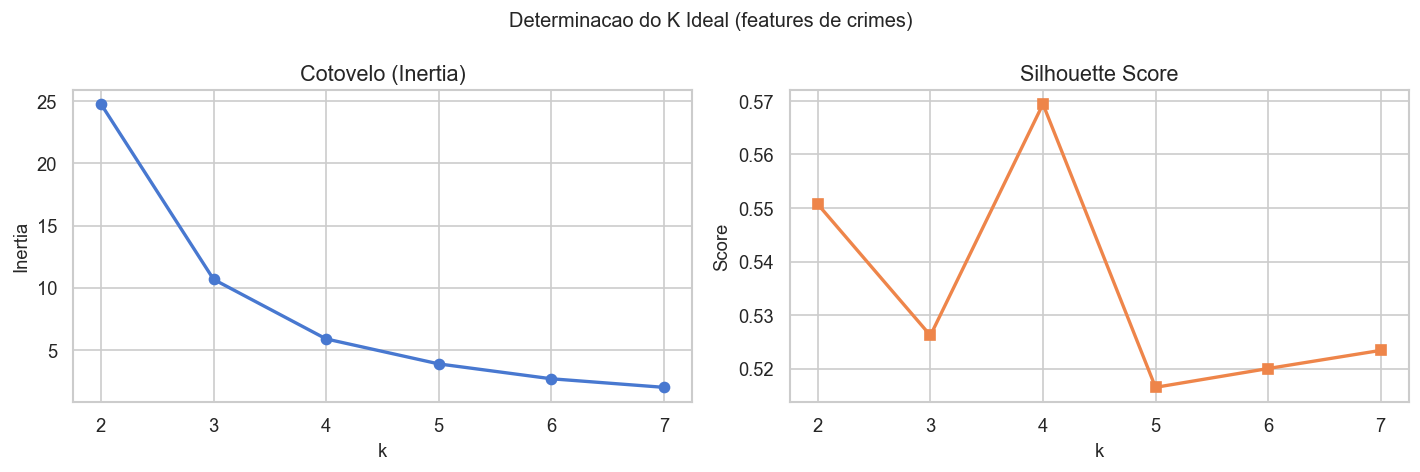

K com maior silhouette: 4  (score=0.569)


In [60]:
inertias, silhouettes = [], []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(feat_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(feat_scaled, lb))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Determinacao do K Ideal (features de crimes)', fontsize=12)

axes[0].plot(list(k_range), inertias, marker='o',
             color=sns.color_palette('muted')[0], linewidth=2)
axes[0].set_title('Cotovelo (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='s',
             color=sns.color_palette('muted')[1], linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

plt.tight_layout(); plt.show()
k_ideal = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'K com maior silhouette: {k_ideal}  (score={max(silhouettes):.3f})')

#quanto menor o cotevelo melhor, mas pode ser subjetivo. O silhouette é mais objetivo, quanto mais proximo de 1 melhor. Aqui o ideal seria k=2, mas k=3 tambem tem um score alto e pode ser interessante para diferenciar os grupos.
#cada K eh um grupo parecido k = 2, 2 grupos parecidos k = 3, 3 grupos parecidos... e assim por diante. O ideal é escolher um K que seja baixo (para facilitar interpretacao) mas que tenha um silhouette alto (para garantir que os grupos sejam bem formados).

In [61]:
km_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
feat['cluster'] = km_final.fit_predict(feat_scaled)

print(f'Distribuicao dos estados por cluster (k={k_ideal}):')
for c in sorted(feat['cluster'].unique()):
    estados = feat[feat['cluster'] == c].index.tolist()
    media   = feat.loc[estados, VAR_PRINCIPAL].mean()
    print(f'  Cluster {c+1} ({len(estados)} estados): {sorted(estados)}')
    print(f'           Media estupro_vulneravel: {media:,.0f}/ano')
print('\nNOTA: clusters preliminares. Refazer apos fusao com IBGE.')

#grupos K=4 (Baixo, 852/ano, Extremo 11023/ano, Muito Baixo 214/ano e Alto 3713/ano).

Distribuicao dos estados por cluster (k=4):
  Cluster 1 (15 estados): ['AC', 'AL', 'AM', 'AP', 'CE', 'DF', 'MA', 'MT', 'PB', 'PE', 'PI', 'RN', 'RR', 'SE', 'TO']
           Media estupro_vulneravel: 852/ano
  Cluster 2 (1 estados): ['SP']
           Media estupro_vulneravel: 11,023/ano
  Cluster 3 (3 estados): ['ES', 'MS', 'RO']
           Media estupro_vulneravel: 214/ano
  Cluster 4 (7 estados): ['BA', 'GO', 'MG', 'PA', 'PR', 'RS', 'SC']
           Media estupro_vulneravel: 3,731/ano

NOTA: clusters preliminares. Refazer apos fusao com IBGE.


---
## 12. Distribuicao de Vitimas por Genero

Desagregacao de vitimas por genero extraida diretamente dos microdados SINESP.
Cobertura de genero: 82-96% das ocorrencias por ano (linhas sem genero registrado
sao atribuidas a 'nao_informado').

Fonte: `data/processed/powerbi_dataset.csv` | Periodo: 2018-2025

In [62]:
# Carregar dataset mestre para analise de genero (2018-2025)
PB_FILE = DATA_DIR / 'powerbi_dataset.csv'
pb = pd.read_csv(PB_FILE)
pb['ano'] = pb['ano'].astype(int)
pb_main = pb[(pb['ano'] >= ANO_INICIO) & (pb['ano'] <= ANO_FIM)].copy()

print(f'Dataset: {pb_main.shape} | Periodo: {ANO_INICIO}-{ANO_FIM}')
print()

for crime, label in [('estupro', 'Estupro (Art. 213)'), ('estupro_vulneravel', 'Estupro de Vulneravel (Art. 217-A)')]:
    fem  = pb_main[f'{crime}_feminino'].sum()
    masc = pb_main[f'{crime}_masculino'].sum()
    nao  = pb_main[f'{crime}_nao_informado'].sum()
    total = pb_main[crime].sum()
    print(f'=== {label} ===')
    print(f'  Total      : {total:,.0f}')
    print(f'  Feminino   : {fem:,.0f} ({fem/total*100:.1f}%)')
    print(f'  Masculino  : {masc:,.0f} ({masc/total*100:.1f}%)')
    print(f'  Nao inform.: {nao:,.0f} ({nao/total*100:.1f}%)')
    print()

Dataset: (216, 32) | Periodo: 2018-2025

=== Estupro (Art. 213) ===
  Total      : 227,202
  Feminino   : 202,242 (89.0%)
  Masculino  : 21,073 (9.3%)
  Nao inform.: 3,887 (1.7%)

=== Estupro de Vulneravel (Art. 217-A) ===
  Total      : 404,500
  Feminino   : 344,911 (85.3%)
  Masculino  : 55,842 (13.8%)
  Nao inform.: 3,747 (0.9%)



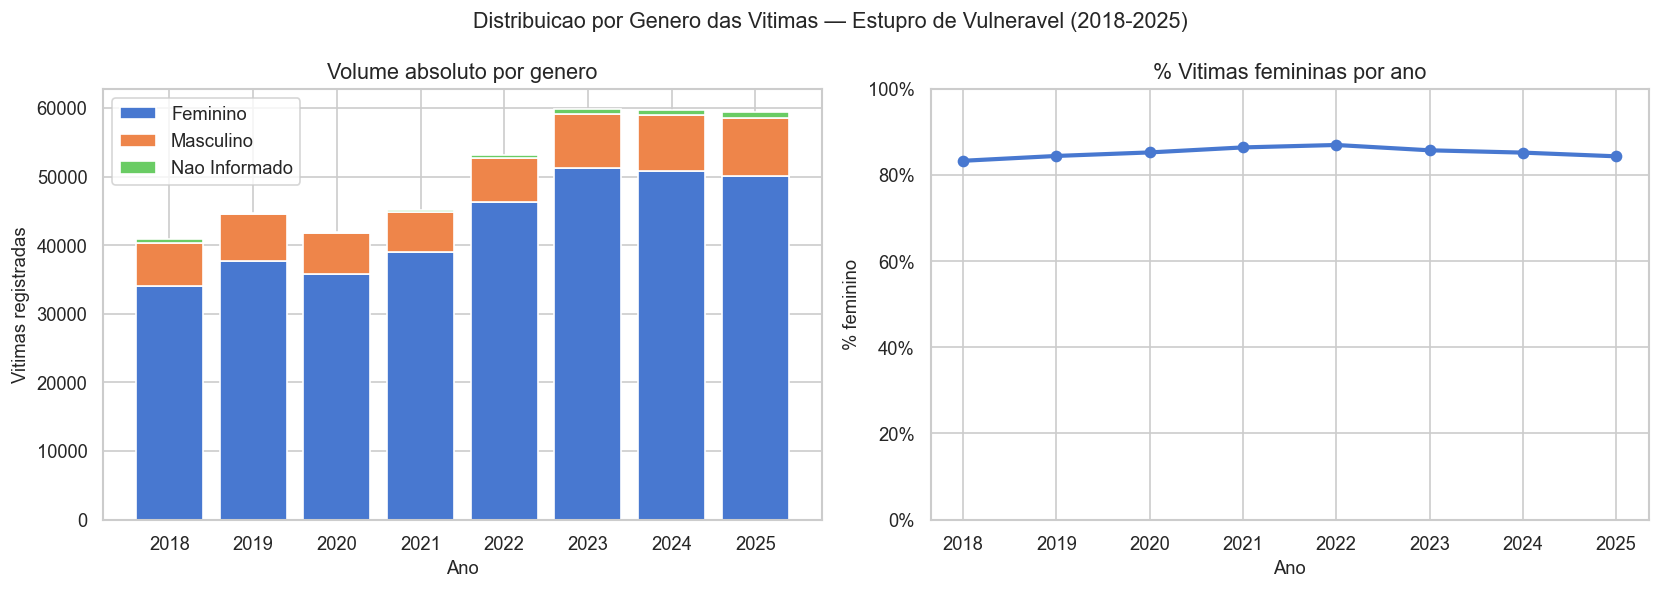

In [63]:
# Evolucao temporal do genero das vitimas de estupro_vulneravel
genero_ano = (
    pb_main
    .groupby('ano')[['estupro_vulneravel_feminino', 'estupro_vulneravel_masculino', 'estupro_vulneravel_nao_informado']]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuicao por Genero das Vitimas — Estupro de Vulneravel (2018-2025)', fontsize=13)

# Stacked bar chart
cores_gen = sns.color_palette('muted', 3)
axes[0].bar(genero_ano['ano'], genero_ano['estupro_vulneravel_feminino'],   label='Feminino',    color=cores_gen[0])
axes[0].bar(genero_ano['ano'], genero_ano['estupro_vulneravel_masculino'],  label='Masculino',   color=cores_gen[1], bottom=genero_ano['estupro_vulneravel_feminino'])
axes[0].bar(genero_ano['ano'], genero_ano['estupro_vulneravel_nao_informado'], label='Nao Informado', color=cores_gen[2],
            bottom=genero_ano['estupro_vulneravel_feminino'] + genero_ano['estupro_vulneravel_masculino'])
axes[0].set_title('Volume absoluto por genero')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Vitimas registradas')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# % Feminino por ano
genero_ano['pct_fem'] = (genero_ano['estupro_vulneravel_feminino'] /
                         (genero_ano['estupro_vulneravel_feminino'] + genero_ano['estupro_vulneravel_masculino'] + genero_ano['estupro_vulneravel_nao_informado']) * 100)
axes[1].plot(genero_ano['ano'], genero_ano['pct_fem'], marker='o', color=cores_gen[0], linewidth=2.5)
axes[1].set_title('% Vitimas femininas por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('% feminino')
axes[1].set_ylim(0, 100)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

---
## 13. Correlacoes com Indicadores Socioeconomicos

Correlacao de Pearson entre `taxa_estupro_vulneravel_por_100k` e cada indicador
socioeconomico integrado ao dataset.

**Fonte:** `data/processed/powerbi_dataset.csv` | Periodo: 2018-2025  
**Chave de significancia:** `***` p<0.001 | `**` p<0.01 | `*` p<0.05 | `n.s.` nao significativo

**Limitacoes de cobertura:**
- `gini`: disponivel 2016-2025 (2026 ausente). No periodo 2018-2025: n maxima=216.
- `taxa_desemprego`: disponivel 2018-2025 exceto 2021 (suprimido no SIDRA a nivel UF). n maxima=189.
- `renda_per_capita`: disponivel 2016-2019 e 2021-2024 (2020 ausente — PNAD suspensa). n maxima=189 no periodo.
- `densidade_demografica`: disponivel 2016-2025. n maxima=216 no periodo.

> Correlacao nao implica causalidade. Os resultados sao descritivos e exploratórios.
> Uma correlacao positiva pode refletir melhor infraestrutura de notificacao nos estados
> mais desenvolvidos (efeito de cobertura), nao necessariamente maior incidencia real.

In [68]:
TAXA_DEP = 'taxa_estupro_vulneravel_por_100k'
SOCIO_VARS = [
    ('gini',                  'Indice de Gini'),
    ('taxa_desemprego',       'Taxa de Desemprego (%)'),
    ('renda_per_capita',      'Renda per Capita (R$)'),
    ('densidade_demografica', 'Densidade Demografica (hab/km2)'),
]

print(f'Variavel dependente: {TAXA_DEP}')
print(f'Periodo de analise : {ANO_INICIO}-{ANO_FIM}')
print()
print(f'{"Variavel":<35} {"r":>8} {"p-valor":>10} {"Sig":>6} {"n":>5}')
print('-' * 68)

corr_results = []
for var, label in SOCIO_VARS:
    subset = pb_main[[TAXA_DEP, var]].dropna()
    n = len(subset)
    if n < 3:
        print(f'{label:<35} {"N/A":>8} {"N/A":>10} {"N/A":>6} {n:>5}')
        continue
    r, p = stats.pearsonr(subset[TAXA_DEP], subset[var])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'{label:<35} {r:>8.3f} {p:>10.4f} {sig:>6} {n:>5}')
    corr_results.append({'var': var, 'label': label, 'r': r, 'p': p, 'n': n, 'sig': sig})

Variavel dependente: taxa_estupro_vulneravel_por_100k
Periodo de analise : 2018-2025

Variavel                                   r    p-valor    Sig     n
--------------------------------------------------------------------
Indice de Gini                        -0.208     0.0021     **   216
Taxa de Desemprego (%)                -0.316     0.0000    ***   189
Renda per Capita (R$)                  0.014     0.8577   n.s.   162
Densidade Demografica (hab/km2)       -0.295     0.0000    ***   216


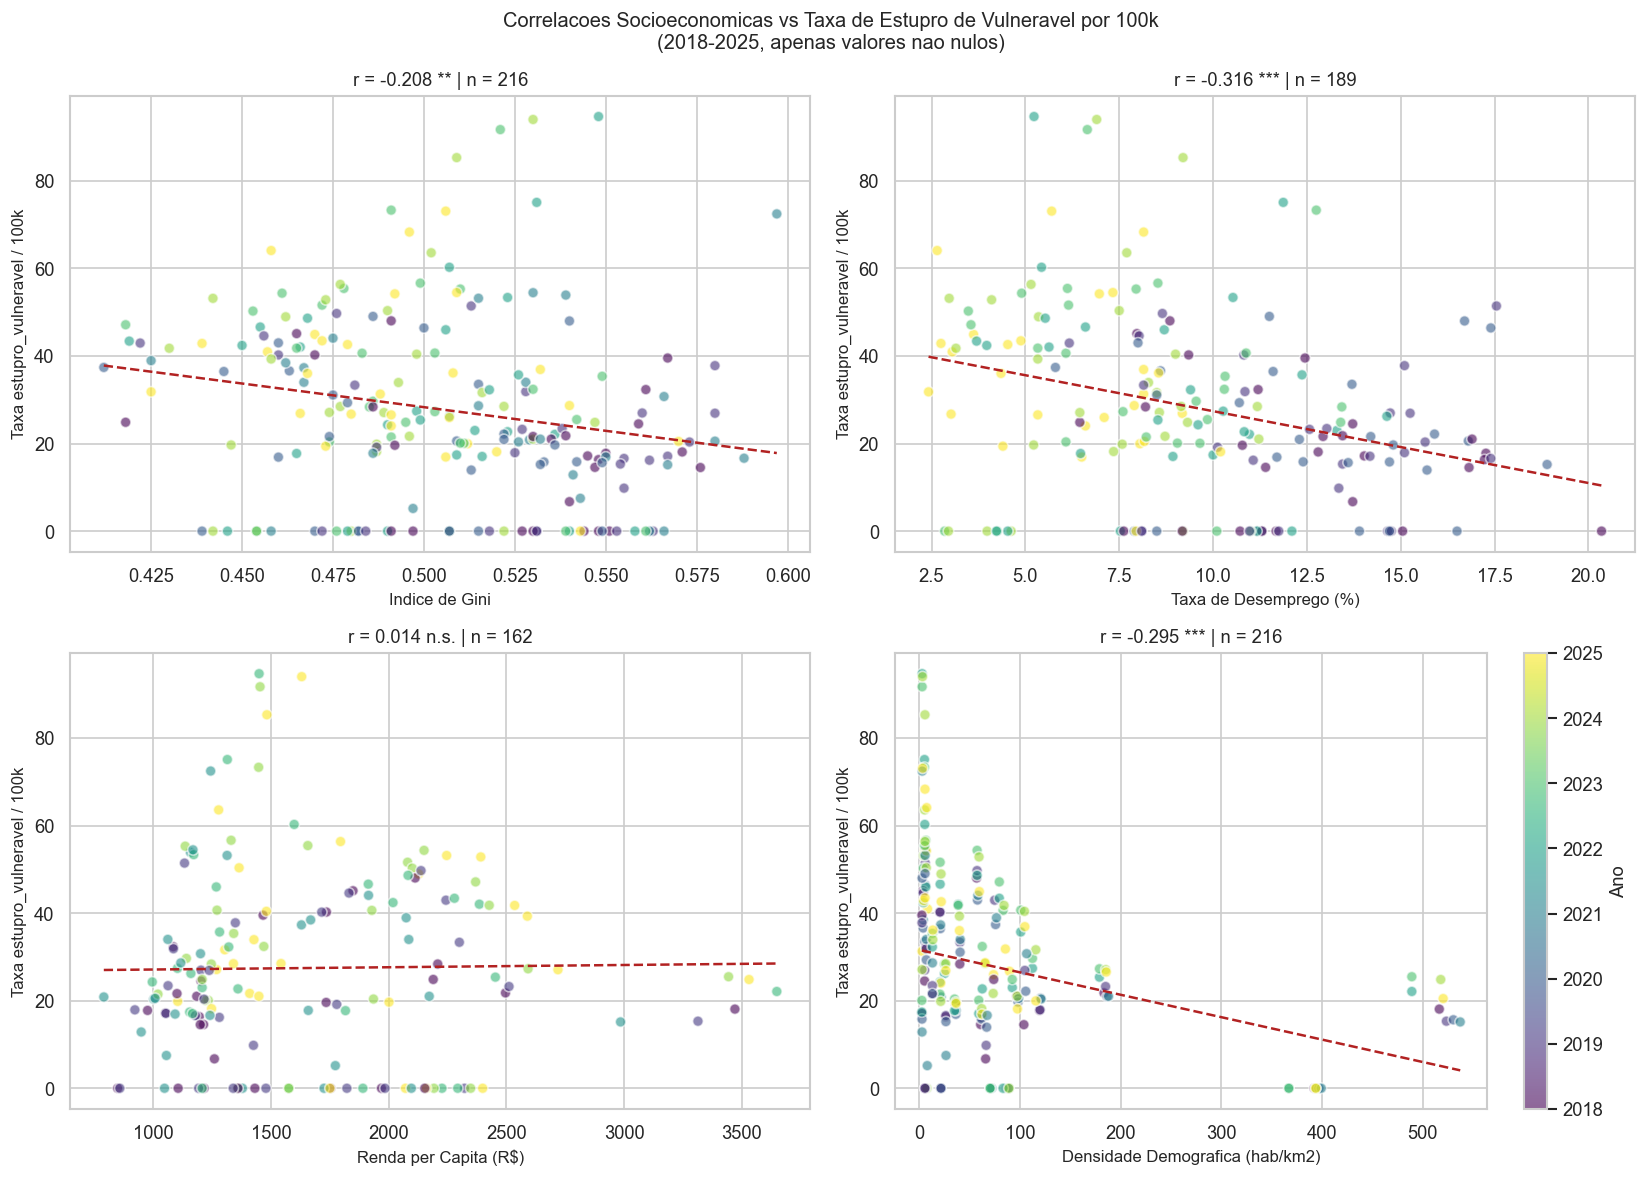

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Correlacoes Socioeconomicas vs Taxa de Estupro de Vulneravel por 100k\n(2018-2025, apenas valores nao nulos)', fontsize=12)

for ax, (var, label) in zip(axes.flat, SOCIO_VARS):
    subset = pb_main[[TAXA_DEP, var, 'ano']].dropna()
    if len(subset) < 3:
        ax.set_visible(False)
        continue
    r, p = stats.pearsonr(subset[TAXA_DEP], subset[var])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

    scatter = ax.scatter(subset[var], subset[TAXA_DEP],
                         c=subset['ano'], cmap='viridis', alpha=0.6, s=40, edgecolors='white')
    # Regression line
    z = np.polyfit(subset[var], subset[TAXA_DEP], 1)
    xline = np.linspace(subset[var].min(), subset[var].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), '--', color='firebrick', linewidth=1.5)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Taxa estupro_vulneravel / 100k', fontsize=10)
    ax.set_title(f'r = {r:.3f} {sig} | n = {len(subset)}', fontsize=11)

plt.colorbar(scatter, ax=axes.flat[-1], label='Ano')
plt.tight_layout()
plt.show()

---
## 14. Limitacoes dos Dados

| Variavel | Limitacao | Anos afetados |
|----------|-----------|---------------|
| INSE | Disponivel apenas para anos oficiais INEP | Apenas 2019 e 2021 — nao interpolar |
| `renda_per_capita` | PNAD suspensa em 2020; 2025 ainda nao publicado | 2020, 2025, 2026 ausentes |
| `taxa_desemprego` | Dados UF suprimidos ("...") no SIDRA em 2021 | 2021 ausente; 2016-2017 fora da serie |
| `gini` | 2026 ainda nao publicado | 2026 ausente |
| 2026 | Ano parcial (jan-mar); excluido da analise principal | — |

**SINESP:** Os dados refletem crimes *registrados*, nao crimes *ocorridos*. Subnotificacao e sistematica e varia por UF, tipo de crime e periodo. Estados com menor infraestrutura de registro podem apresentar taxas mais baixas que nao refletem ausencia real de crimes.

**Rio de Janeiro:** Zero registros de `estupro_vulneravel` em todos os anos do SINESP. Tratado como falha sistematica de notificacao, nao como ausencia real.

**Correlacao nao implica causalidade.** Todos os resultados sao descritivos e correlacionais.

---
## 16. Conclusao e Consideracoes Finais

### 16.1 Resumo Geral da Analise

| Secao | Dimensao analisada | Principal resultado |
|---|---|---|
| 3-4 | Qualidade e cobertura dos dados | RJ: zero sistematico em estupro_vulneravel (todos os anos); 10 UFs com subnotificacao em 2016-2017 |
| 5-6 | Estatisticas descritivas e distribuicao | Alta assimetria nos contadores absolutos; SP domina em volume, estados do Norte lideram em taxa/100k |
| 7 | Tendencia temporal (2018-2025) | Crescimento de **+45,3%** em estupro_vulneravel; proporcao sobre total: 56% -> 71% |
| 8 | Analise geografica | Ranking absoluto: SP, PR, RS, MG, PA; ranking por taxa/100k: TO, RR, AP, GO |
| 9a | Correlacao entre variaveis de crime | Pearson r = 0,62 (p < 0,001) entre estupro e estupro_vulneravel -- crescem juntos por UF/ano |
| 9b | Correlacao com INSE (2019 e 2021) | Correlacoes fracas e ambiguas; sinal significativo aponta para **efeito de notificacao**, nao relacao causal |
| 10b | Clusterizacao K-Means (k=3) | Tres perfis: risco mais alto (Sul/SE/CO), risco mais baixo (Norte/NE), padrao atipico (RJ, RO, ES, MS) |

---

### 16.2 Principais Achados

**1. Crescimento expressivo e continuo de estupro de vulneravel**

Entre 2018 e 2025, os registros de estupro de vulneravel no SINESP cresceram 45,3%,
passando de 40.848 para 59.366 ocorrencias anuais. O crime ja representa **71% de todos
os crimes sexuais registrados** nas fontes analisadas. Parte desse crescimento pode refletir
melhora na cobertura e na notificacao ao longo dos anos, e nao necessariamente aumento
real da incidencia.

**2. A correlacao entre INSE e taxas de crime e fraca e metodologicamente ambigua**

Nenhuma variavel do INSE apresentou correlacao significativa com `taxa_estupro_vulneravel_por_100k`.
Para `taxa_estupro_por_100k`, as unicas correlacoes significativas foram negativas com os niveis
socioeconomicos mais baixos (nivel_1: r = -0,391; nivel_2: r = -0,308) e positiva com nivel_5
(r = +0,342). Esse padrao -- estados mais pobres com menores taxas registradas -- e consistente
com **subnotificacao estrutural**: regioes menos desenvolvidas registram menos crimes, nao porque
tenham menos crimes, mas porque tem menor infraestrutura de captacao e registro.

**3. Os clusters refletem capacidade de notificacao, nao risco real**

O K-Means (k=3, silhouette = 0,491) produziu tres agrupamentos:

- **Risco observado mais alto** (9 UFs: Sul, Sudeste, CO): maior INSE, maiores taxas registradas
- **Risco observado mais baixo** (14 UFs: Norte, Nordeste): menor INSE, menores taxas registradas
- **Padrao atipico** (5 UFs: ES, MS, RJ, RO, TO): alta taxa de estupro mas estupro_vulneravel proxima de zero

O terceiro cluster e o achado mais relevante: indica falha grave de notificacao especifica
para crimes contra vulneraveis. RJ e o caso mais critico -- zero registros de estupro_vulneravel
em todos os anos do SINESP.

---

### 16.3 Limitacoes Criticas

1. **Subnotificacao nao controlada:** as taxas refletem ocorrencias *registradas*, nao ocorrencias
   reais. A variacao entre estados pode ser explicada majoritariamente pela capacidade institucional
   de registro.

2. **INSE disponivel apenas para 2019 e 2021:** a janela de correlacao e limitada a n = 54
   observacoes e dois pontos temporais. Resultados nao sao generalizaveis.

3. **Variaveis socioeconomicas ausentes:** renda per capita, indice Gini, taxa de desemprego,
   percentual de pobreza e densidade demografica nao foram incorporados. Sao confundidores
   importantes que impedem separar o efeito da pobreza do efeito da subnotificacao.

4. **Crimes ausentes do escopo:** `sequestro` e `exploracao_infantil` nao estao disponiveis
   no SINESP e nao foram analisados nesta versao.

5. **RJ -- caso omisso estrutural:** zero registros de estupro_vulneravel em todos os anos.
   Qualquer analise nacional que ignore essa ausencia subestima gravemente a magnitude do problema.

> **Aviso metodologico:** Esta analise e integralmente descritiva e correlacional.
> Nenhuma relacao de causalidade e estabelecida ou inferida.
> **Correlacao nao implica causalidade.**

---

### 16.4 Arquivos Gerados por Este Projeto

| Arquivo | Descricao |
|---|---|
| `data/processed/sinesp_crimes.csv` | SINESP padronizado (27 UFs x 11 anos, 2016-2026) |
| `data/processed/inep_inse.csv` | INSE estadual agregado (27 UFs x 2 anos: 2019 e 2021) |
| `data/processed/ibge_populacao.csv` | Populacao estadual IBGE (27 UFs x 10 anos: 2016-2025) |
| `data/processed/sinesp_inse_pop_left_join.csv` | SINESP + INSE + populacao, todos os anos |
| `data/processed/sinesp_inse_pop_inner_join.csv` | SINESP + INSE + populacao, apenas 2019 e 2021 |
| `data/processed/sinesp_inse_pop_clusters.csv` | Dataset com cluster_id e perfil atribuido |
| `data/processed/powerbi_dataset.csv` | Dataset consolidado para o Power BI |
| `reports/relatorio_final.md` | Relatorio final do projeto em Markdown |